# Barter Analysis Active Users

Analyses
- Percentage of users that register / apply
- Percentage of Applications that ultimately get accepted/ finished
- Compute "stable userbase":
    - We see graphs across categories/regions move together. This indicates that some external factors are driving growth (such as advertising campaigns). Although they (should) lead to more users, this causes waves of users coming in and leaving. I can separate the "harde kern" from the transient users by checking applications:
        - E.g., how many users do we have that apply to a deal at least 5 times a month? Moreover, need some kind of "gravity" metric; users that stay on the platform and use it over consecutive periods of time

Comments
- Should maybe focus on avg apps per deal instead of active users?

In [1]:
import os
from dotenv import load_dotenv
from sqlalchemy import create_engine
from sqlalchemy import text

import numpy as np
import pandas as pd
from collections import defaultdict

In [2]:
from src import paths
# Applications
df_apps = pd.read_parquet(paths.RAW_DATA_DIR / 'BARTER_DEAL_APPLICATIONS.parquet')
df_apps['application_created_at'] = pd.to_datetime(df_apps['application_created_at']).dt.normalize()

df_apps = df_apps.sort_values('application_created_at').reset_index(drop=True)
df_apps = df_apps[df_apps.application_created_at < '2026-01-30']
# df_apps.rename(columns={'country': 'country_partners'})

# Deals
df_deals = pd.read_parquet(paths.PROCESSED_DATA_DIR / 'BARTER_DEALS_FEATURES.parquet')

df_deals = df_deals[df_deals.created_at < '2026-01-30']


# Data prep

In [3]:
df_apps.loc[df_apps['reviews_count_creators'] == 0,'rating_creators'] = pd.NA
df_apps['rating_creator_rounded'] = ((df_apps['rating_creators'] * 2).round(0))/2


# Define the edges of your buckets
# Note: -1 is used as the start to ensure 0 is included in the first bucket
bins = [-1, 0, 5, 10, 15, 20, 30, 40]

# Define the labels for the buckets
labels = ['0', '1-5', '6-10', '11-15', '16-20', '21-30', '31-40']

df_apps['reviews_bucket'] = pd.cut(
    df_apps['reviews_count_creators'], 
    bins=bins, 
    labels=labels
)

Create long format dataset, with relevant grouping columns. We only retain the groups that have a minimum of n observations (e.g., very small cities should not be included in the plot). 

In [4]:
import pandas as pd

def get_daily_uniques(target_dates_ns, event_dates, creators, window_days):
    window_ns = pd.Timedelta(days=window_days).value
    n_events = len(event_dates)
    results = []
    
    counts = defaultdict(int)
    unique_count = 0
    
    left_ptr = 0
    right_ptr = 0
    
    # Iterate through each calendar day
    for current_day_ns in target_dates_ns:
        min_time_ns = current_day_ns - window_ns
        
        # EXPAND: Add events that happened before the current day
        while right_ptr < n_events and event_dates[right_ptr] < current_day_ns:
            inf = creators[right_ptr]
            if counts[inf] == 0:
                unique_count += 1
            counts[inf] += 1
            right_ptr += 1
            
        # SHRINK: Remove events that happened on or before the min_time (falling out of window)
        while left_ptr < right_ptr and event_dates[left_ptr] <= min_time_ns:
            inf = creators[left_ptr]
            counts[inf] -= 1
            if counts[inf] == 0:
                unique_count -= 1
            left_ptr += 1
            
        # Record the snapshot for this specific day
        results.append(unique_count)
        
    return results


def get_independent_actives(df, columns_list):
    """
    Calculates rolling active unique creators for each column independently,
    stacking them into a single 'Category' and 'Value' format.
    """
    # 1. Sort the main dataframe once (CRITICAL)
    df = df.sort_values('application_created_at').reset_index(drop=True)
    
    # 2. Establish the universal daily date range
    dateranges = pd.date_range(
        start=df['application_created_at'].min().normalize(), 
        end=df['application_created_at'].max().normalize(), 
        freq='D'
    )
    target_dates_ns = dateranges.astype('int64').values
    
    all_segments = []
    
    # 3. Loop through each column independently
    for col in columns_list:
        # Find the unique values for this specific column
        unique_values = df[col].dropna().unique()
        
        for val in unique_values:
            # Filter the data for just this value
            df_subset = df[df[col] == val]
            
            # Extract arrays for speed
            event_dates = df_subset['application_created_at'].astype('int64').values
            influencers = df_subset['creator_id'].values
            
            # Calculate the rolling metrics
            active_30 = get_daily_uniques(target_dates_ns, event_dates, influencers, 30)
            active_7 = get_daily_uniques(target_dates_ns, event_dates, influencers, 7)
            
            # Build the Tidy DataFrame for this specific slice
            df_temp = pd.DataFrame({
                'date': dateranges,
                'category': col,       # e.g., 'gender_creator' or 'country'
                'value': val,          # e.g., 'male' or 'Germany'
                'active_last_month': active_30,
                'active_last_week': active_7
            })
            
            all_segments.append(df_temp)
            
    # 4. Combine everything into one master DataFrame
    return pd.concat(all_segments, ignore_index=True)



def filter_long_tail(df, columns_list, min_events=50):
    """
    Replaces rare categories in specified columns with pd.NA.
    This prevents downstream functions from processing useless groups.
    """
    # Create a copy so we don't accidentally mutate your raw raw data
    df_cleaned = df.copy()
    
    for col in columns_list:
        # 1. Count how many rows exist for each category
        counts = df_cleaned[col].value_counts()
        
        # 2. Keep only the categories that meet your threshold
        valid_categories = counts[counts >= min_events].index
        
        # 3. Overwrite anything NOT in the valid list with pd.NA
        # Note: ~ is the pandas operator for "NOT"
        df_cleaned.loc[~df_cleaned[col].isin(valid_categories), col] = pd.NA
        
        # Optional: Print a quick summary of what was dropped
        dropped_count = len(counts) - len(valid_categories)
        print(f"[{col}] Kept top {len(valid_categories)} categories. Dropped {dropped_count} small categories to NA.")
        
    return df_cleaned



def get_rolling_avg_apps_per_deal(target_dates_ns, event_dates, deal_ids, window_days):
    window_ns = pd.Timedelta(days=window_days).value
    n_events = len(event_dates)
    results = []
    
    counts = defaultdict(int)
    unique_deals = 0
    
    left_ptr = 0
    right_ptr = 0
    
    # Iterate through each calendar day
    for current_day_ns in target_dates_ns:
        min_time_ns = current_day_ns - window_ns
        
        # EXPAND: Add events to the right of the window
        while right_ptr < n_events and event_dates[right_ptr] < current_day_ns:
            d_id = deal_ids[right_ptr]
            if counts[d_id] == 0:
                unique_deals += 1
            counts[d_id] += 1
            right_ptr += 1
            
        # SHRINK: Remove events falling out the left of the window
        while left_ptr < right_ptr and event_dates[left_ptr] <= min_time_ns:
            d_id = deal_ids[left_ptr]
            counts[d_id] -= 1
            if counts[d_id] == 0:
                unique_deals -= 1
            left_ptr += 1
            
        # THE MAGIC TRICK: Total apps is just the number of elements between pointers
        total_apps = right_ptr - left_ptr
        
        # Calculate Average (protect against division by zero if there are no deals)
        if unique_deals > 0:
            avg = total_apps / unique_deals
        else:
            avg = np.nan # Use NaN so the plot line breaks cleanly instead of dropping to 0
            
        results.append(avg)
        
    return results




In [44]:
cols_to_segment = [
    'gender_creators', 
    'city_creators', 
    'country_creators', 
    'city_company_locations', 
    'country_company_locations',
    'deal_type_deals',
    'application_status',
    'rating_creator_rounded',
    'reviews_bucket'
]

df_apps_filtered = filter_long_tail(df_apps, cols_to_segment, min_events=100)
df_master_long = get_independent_actives(df_apps_filtered, cols_to_segment)

[gender_creators] Kept top 3 categories. Dropped 0 small categories to NA.
[city_creators] Kept top 310 categories. Dropped 691 small categories to NA.
[country_creators] Kept top 8 categories. Dropped 7 small categories to NA.
[city_company_locations] Kept top 171 categories. Dropped 341 small categories to NA.
[country_company_locations] Kept top 5 categories. Dropped 11 small categories to NA.
[deal_type_deals] Kept top 2 categories. Dropped 0 small categories to NA.
[application_status] Kept top 5 categories. Dropped 0 small categories to NA.
[rating_creator_rounded] Kept top 8 categories. Dropped 0 small categories to NA.
[reviews_bucket] Kept top 7 categories. Dropped 0 small categories to NA.


In [6]:
df_apps_filtered = df_apps_filtered.sort_values('application_created_at').reset_index(drop=True)


event_dates = df_apps_filtered['application_created_at'].astype('int64').values
dateranges = pd.date_range(
    start=df_apps_filtered['application_created_at'].min().normalize(), 
    end=df_apps_filtered['application_created_at'].max().normalize(), 
    freq='D'
)
target_dates_ns = dateranges.astype('int64').values


###### Nr of active users

creators = df_apps['creator_id'].values
# Convert the target daily dates to nanoseconds
df_active_creators = pd.DataFrame({'date': dateranges})
df_active_creators['active_last_month'] = get_daily_uniques(
    target_dates_ns, event_dates, creators, window_days=30
)
df_active_creators['active_last_week'] = get_daily_uniques(
    target_dates_ns, event_dates, creators, window_days=7
)


####### Average applications per deal

# 1. Prepare the Data (Sorting is mandatory for the pointer logic!)
deal_ids = df_apps_filtered['deal_id'].values

# Store in a temporary DataFrame for plotting
df_rolling_plot = pd.DataFrame({
    'date': dateranges
})

df_rolling_plot['avg_apps_last_week'] = get_rolling_avg_apps_per_deal(target_dates_ns, event_dates, deal_ids, window_days=7)
df_rolling_plot['avg_apps_last_month'] = get_rolling_avg_apps_per_deal(target_dates_ns, event_dates, deal_ids, window_days=30)
# To get the daily velocity of a deal:
# df_rolling_plot['daily_velocity_7d'] = df_rolling_plot['avg_apps_last_week'] / 7
# df_rolling_plot['daily_velocity_30d'] = df_rolling_plot['avg_apps_last_month'] / 30


###### Nr of deals posted
# Normalize dates to midnight
df_deals['created_at'] = pd.to_datetime(df_deals['created_at']).dt.normalize()

# Count how many deals were created on each specific day
daily_deals = df_deals.groupby('created_at').size()

# Establish the continuous daily calendar
start_date = daily_deals.index.min()
end_date = daily_deals.index.max()
dateranges = pd.date_range(start=start_date, end=end_date, freq='D')

# Reindex to fill in days where 0 deals were created
daily_deals = daily_deals.reindex(dateranges, fill_value=0)

# Calculate the rolling sums (Native C-optimized Pandas)
# min_periods=1 ensures the line starts immediately instead of waiting 30 days
rolling_7d = daily_deals.rolling(window=7, min_periods=1).sum()
rolling_30d = daily_deals.rolling(window=30, min_periods=1).sum()

df_deals_plot = pd.DataFrame({
    'date': dateranges,
    'deals_last_week': rolling_7d,
    'deals_last_month': rolling_30d
})



# 1. Merge on 'date' using an inner join to keep only overlapping days
df_ratio = pd.merge(
    df_active_creators, 
    df_deals_plot, 
    on='date', 
    how='inner'
)

df_ratio['creators_per_deal_7d'] = df_ratio['active_last_week'] / df_ratio['deals_last_week']
df_ratio['creators_per_deal_30d'] = df_ratio['active_last_month'] / df_ratio['deals_last_month']
df_ratio.replace([np.inf, -np.inf], np.nan, inplace=True)


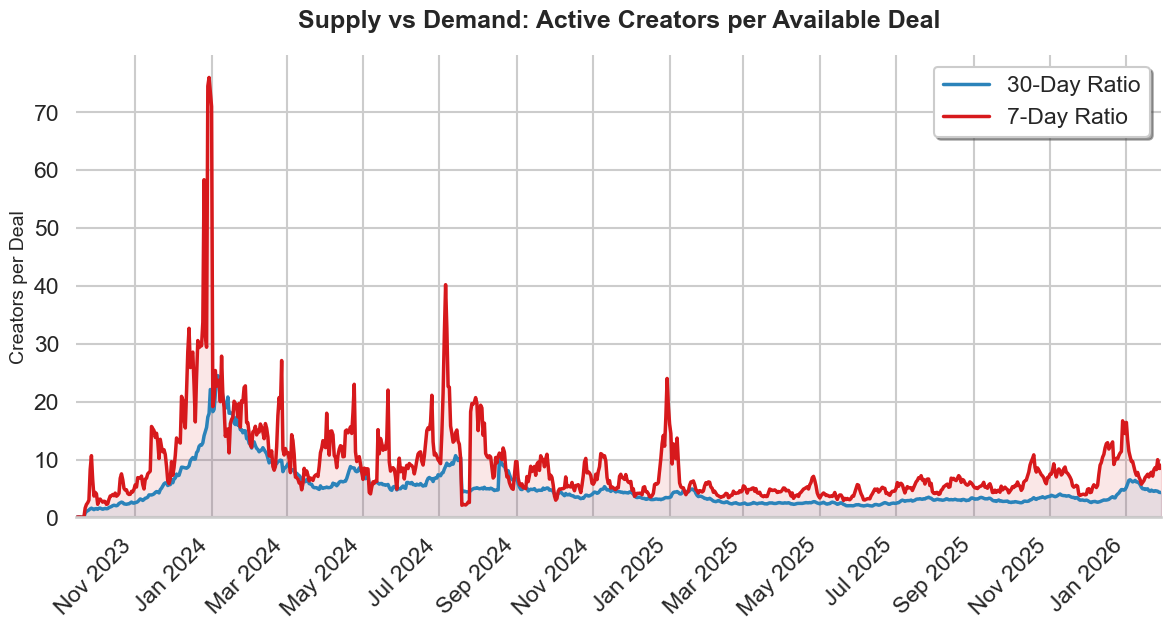

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates

sns.set_theme(style="whitegrid", context="talk")
plt.figure(figsize=(14, 6))

# Plotting the Creators per Deal ratio
plt.plot(df_ratio['date'], df_ratio['creators_per_deal_30d'], 
         label='30-Day Ratio', color='#2b83ba', linewidth=2.5)
plt.plot(df_ratio['date'], df_ratio['creators_per_deal_7d'], 
         label='7-Day Ratio', color='#d7191c', linewidth=2.5)

plt.fill_between(df_ratio['date'], df_ratio['creators_per_deal_30d'], color='#2b83ba', alpha=0.1)
plt.fill_between(df_ratio['date'], df_ratio['creators_per_deal_7d'], color='#d7191c', alpha=0.1)

plt.title('Supply vs Demand: Active Creators per Available Deal', fontsize=18, fontweight='bold', pad=20)
plt.ylabel('Creators per Deal', fontsize=14)

ax = plt.gca()
ax.set_ylim(bottom=0)
ax.margins(x=0)
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))        
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y')) 
plt.xticks(rotation=45, ha='right')

sns.despine(left=True, bottom=False)
plt.legend(loc='upper right', frameon=True, shadow=True)
plt.show()

# Plots

## Static plots

### Main platform health plots

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates

def plot_marketplace_scale(df_active_creators, df_deals_plot):
    sns.set_theme(style="whitegrid", context="talk")
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 9), sharex=True, layout='constrained')

    fig.suptitle('Marketplace Scale: Active Creators & Inventory Volumes', 
                 fontsize=24, fontweight='bold')

    # ==========================================
    # PANEL 1: Unique Active Creators
    # ==========================================
    ax1.plot(df_active_creators['date'], df_active_creators['active_last_month'], 
             label='30-Day Active', color='#2b83ba', linewidth=2.5)
    ax1.plot(df_active_creators['date'], df_active_creators['active_last_week'], 
             label='7-Day Active', color='#d7191c', linewidth=2.5)

    ax1.fill_between(df_active_creators['date'], df_active_creators['active_last_month'], color='#2b83ba', alpha=0.1)
    ax1.fill_between(df_active_creators['date'], df_active_creators['active_last_week'], color='#d7191c', alpha=0.1)

    ax1.set_title('1. Unique Active Creators', fontsize=18, fontweight='bold', loc='left')
    ax1.set_ylabel('Active Creators', fontsize=14)
    ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))
    ax1.legend(loc='upper left', frameon=True, shadow=True)

    # ==========================================
    # PANEL 2: Rolling Volume of New Deals
    # ==========================================
    ax2.plot(df_deals_plot['date'], df_deals_plot['deals_last_month'], 
             label='Deals (Last 30 Days)', color='#2b83ba', linewidth=2.5)
    ax2.plot(df_deals_plot['date'], df_deals_plot['deals_last_week'], 
             label='Deals (Last 7 Days)', color='#d7191c', linewidth=2.5)

    ax2.fill_between(df_deals_plot['date'], df_deals_plot['deals_last_month'], color='#2b83ba', alpha=0.1)
    ax2.fill_between(df_deals_plot['date'], df_deals_plot['deals_last_week'], color='#d7191c', alpha=0.1)

    ax2.set_title('2. New Deals Created', fontsize=18, fontweight='bold', loc='left')
    ax2.set_ylabel('Number of Deals', fontsize=14)
    ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))
    ax2.legend(loc='upper left', frameon=True, shadow=True)

    # ==========================================
    # GLOBAL FORMATTING
    # ==========================================
    for ax in [ax1, ax2]:
        ax.set_ylim(bottom=0)
        ax.margins(x=0) 
        sns.despine(ax=ax, left=True, bottom=False)

    ax2.xaxis.set_major_locator(mdates.MonthLocator())        
    ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y')) 
    ax2.tick_params(axis='x', rotation=45)

    # Keynote export parameters
    # plt.savefig('slide1_marketplace_scale.png', dpi=300, transparent=True)
    plt.show()
    plt.close()

In [9]:
import pandas as pd

# 1. Ensure the date column is standard datetime
df_active_creators['date'] = pd.to_datetime(df_active_creators['date'])

# 2. Extract the year
df_active_creators['year'] = df_active_creators['date'].dt.year

# 3. Filter strictly for 2024 and 2025
df_wau_yoy = df_active_creators[df_active_creators['year'].isin([2024, 2025])]

# 4. Group by year to find the average Weekly Active Creators (WAU)
df_creator_summary = df_wau_yoy.groupby('year')['active_last_week'].mean().reset_index()
df_creator_summary.rename(columns={'active_last_week': 'avg_weekly_active_creators'}, inplace=True)

# 5. Extract values to calculate the YoY percentage safely
# (Using .get to avoid errors if a year happens to be missing in a subset)
wau_2024 = df_creator_summary.loc[df_creator_summary['year'] == 2024, 'avg_weekly_active_creators'].sum()
wau_2025 = df_creator_summary.loc[df_creator_summary['year'] == 2025, 'avg_weekly_active_creators'].sum()

if wau_2024 > 0:
    yoy_growth_pct = ((wau_2025 - wau_2024) / wau_2024) * 100
else:
    yoy_growth_pct = float('nan')

# 6. Print the cleanly formatted results for your presentation
print("=== Creator Base YoY Growth ===")
print(f"2024 Average WAU: {wau_2024:,.0f}")
print(f"2025 Average WAU: {wau_2025:,.0f}")
print(f"YoY Growth:       {yoy_growth_pct:+.1f}%\n")

=== Creator Base YoY Growth ===
2024 Average WAU: 229
2025 Average WAU: 440
YoY Growth:       +92.3%



In [10]:
import pandas as pd

# 1. Ensure the date column is a standard datetime object
df_deals_plot['date'] = pd.to_datetime(df_deals_plot['date'])

# 2. Extract the year
df_deals_plot['year'] = df_deals_plot['date'].dt.year

# 3. Filter strictly for 2024 and 2025
df_deals_yoy = df_deals_plot[df_deals_plot['year'].isin([2024, 2025])]

# 4. Group by year to find the average rolling Weekly Deals
df_deals_summary = df_deals_yoy.groupby('year')['deals_last_week'].mean().reset_index()
df_deals_summary.rename(columns={'deals_last_week': 'avg_weekly_deals'}, inplace=True)

# 5. Extract values to calculate the YoY percentage safely
deals_2024 = df_deals_summary.loc[df_deals_summary['year'] == 2024, 'avg_weekly_deals'].sum()
deals_2025 = df_deals_summary.loc[df_deals_summary['year'] == 2025, 'avg_weekly_deals'].sum()

if deals_2024 > 0:
    deals_yoy_growth_pct = ((deals_2025 - deals_2024) / deals_2024) * 100
else:
    deals_yoy_growth_pct = float('nan')

# 6. Print the cleanly formatted results
print("=== Deal Inventory YoY Growth ===")
print(f"2024 Avg Weekly Deals: {deals_2024:,.0f}")
print(f"2025 Avg Weekly Deals: {deals_2025:,.0f}")
print(f"YoY Growth:            {deals_yoy_growth_pct:+.1f}%\n")

=== Deal Inventory YoY Growth ===
2024 Avg Weekly Deals: 28
2025 Avg Weekly Deals: 84
YoY Growth:            +195.4%



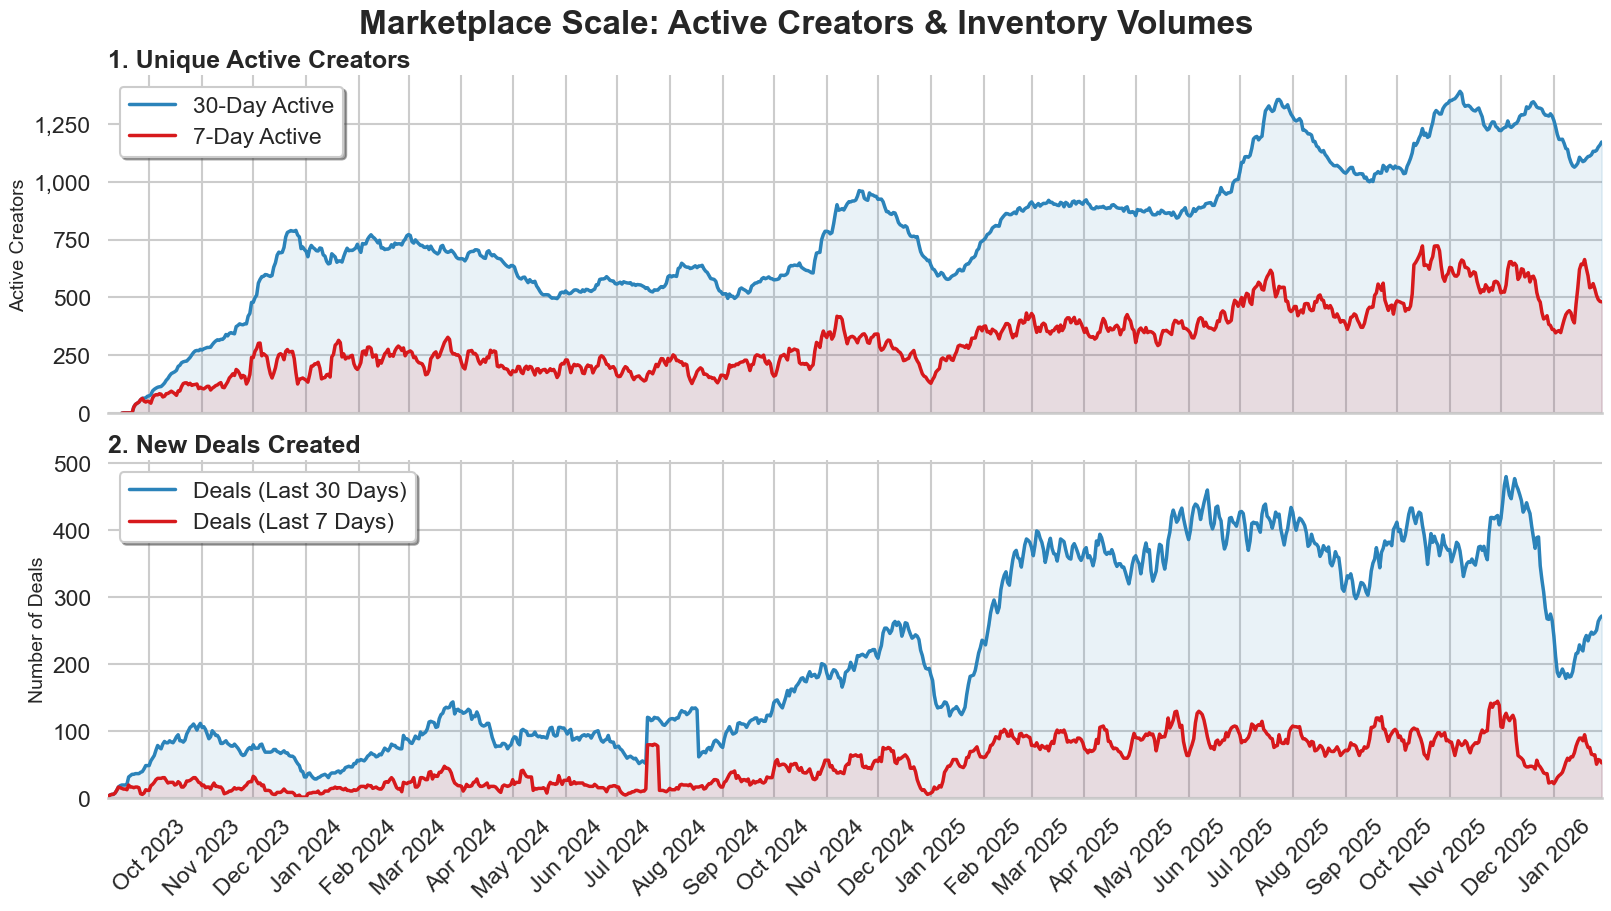

In [11]:
plot_marketplace_scale(df_active_creators, df_deals_plot)

In [12]:
import pandas as pd

def plot_marketplace_density(df_active_creators, df_deals_plot, df_rolling_plot):
    # Calculate the new Supply vs Demand ratio safely
    df_ratio = pd.merge(df_active_creators, df_deals_plot, on='date', how='inner')
    
    # Avoid division by zero
    df_ratio['creators_per_deal_30d'] = df_ratio['active_last_month'] / df_ratio['deals_last_month'].replace(0, pd.NA)
    df_ratio['creators_per_deal_7d'] = df_ratio['active_last_week'] / df_ratio['deals_last_week'].replace(0, pd.NA)

    sns.set_theme(style="whitegrid", context="talk")
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 9), sharex=True, layout='constrained')

    fig.suptitle('Marketplace Density: Engagement and Supply Ratios', 
                 fontsize=24, fontweight='bold')

    # ==========================================
    # PANEL 1: Average Applications Per Deal
    # ==========================================
    ax1.plot(df_rolling_plot['date'], df_rolling_plot['avg_apps_last_month'], 
             label='Avg Apps/Deal (Last 30 Days)', color='#2b83ba', linewidth=2.5)
    ax1.plot(df_rolling_plot['date'], df_rolling_plot['avg_apps_last_week'], 
             label='Avg Apps/Deal (Last 7 Days)', color='#d7191c', linewidth=2.5)

    ax1.fill_between(df_rolling_plot['date'], df_rolling_plot['avg_apps_last_month'], color='#2b83ba', alpha=0.1)
    ax1.fill_between(df_rolling_plot['date'], df_rolling_plot['avg_apps_last_week'], color='#d7191c', alpha=0.1)

    ax1.set_title('1. Density: Average Applications per Deal', fontsize=18, fontweight='bold', loc='left')
    ax1.set_ylabel('Avg Apps / Deal', fontsize=14)
    ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:.1f}'))
    ax1.legend(loc='upper right', frameon=True, shadow=True)

    # ==========================================
    # PANEL 2: Supply vs Demand (Creators Per Deal)
    # ==========================================
    ax2.plot(df_ratio['date'], df_ratio['creators_per_deal_30d'], 
             label='Creators/Deal (Last 30 Days)', color='#2b83ba', linewidth=2.5)
    ax2.plot(df_ratio['date'], df_ratio['creators_per_deal_7d'], 
             label='Creators/Deal (Last 7 Days)', color='#d7191c', linewidth=2.5)

    ax2.fill_between(df_ratio['date'], df_ratio['creators_per_deal_30d'], color='#2b83ba', alpha=0.1)
    ax2.fill_between(df_ratio['date'], df_ratio['creators_per_deal_7d'], color='#d7191c', alpha=0.1)

    ax2.set_title('2. Supply vs. Demand: Active Creators Per Deal', fontsize=18, fontweight='bold', loc='left')
    ax2.set_ylabel('Creators / Deal', fontsize=14)
    ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:.1f}'))
    ax2.legend(loc='upper right', frameon=True, shadow=True)

    # ==========================================
    # GLOBAL FORMATTING
    # ==========================================
    for ax in [ax1, ax2]:
        ax.set_ylim(bottom=0)
        ax.margins(x=0) 
        sns.despine(ax=ax, left=True, bottom=False)

    ax2.xaxis.set_major_locator(mdates.MonthLocator())        
    ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y')) 
    ax2.tick_params(axis='x', rotation=45)

    ax2.set_ylim(0, 30)

    # Keynote export parameters
    # plt.savefig('slide2_marketplace_density.png', dpi=300, transparent=True)
    plt.show()
    plt.close()

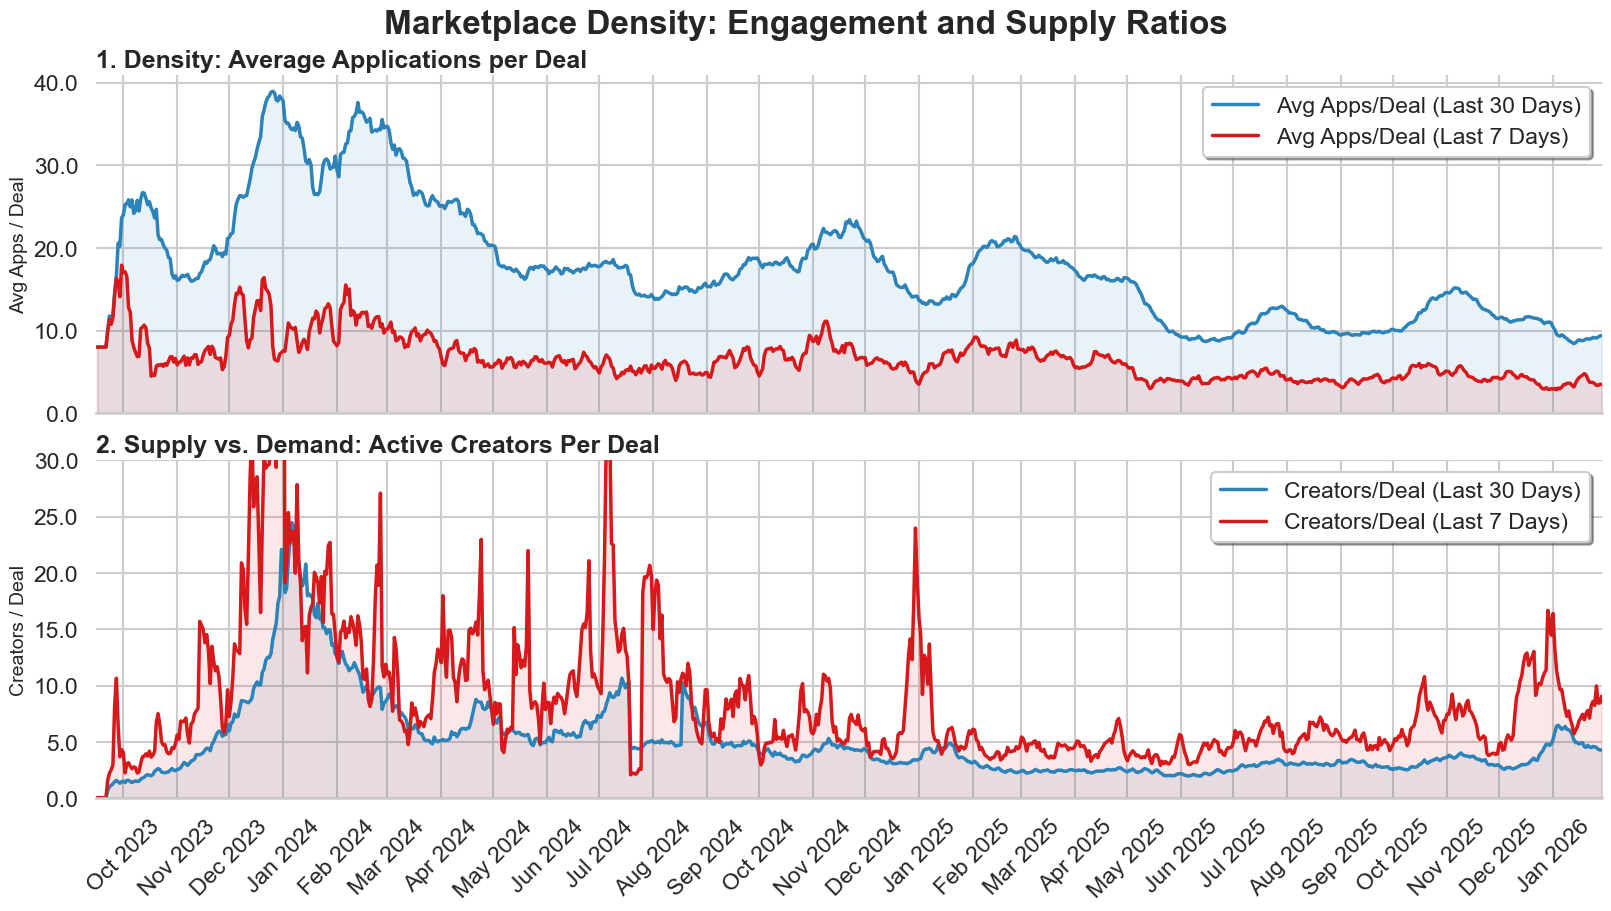

In [13]:
plot_marketplace_density(df_active_creators, df_deals_plot, df_rolling_plot)

### Main platform health plot (old)

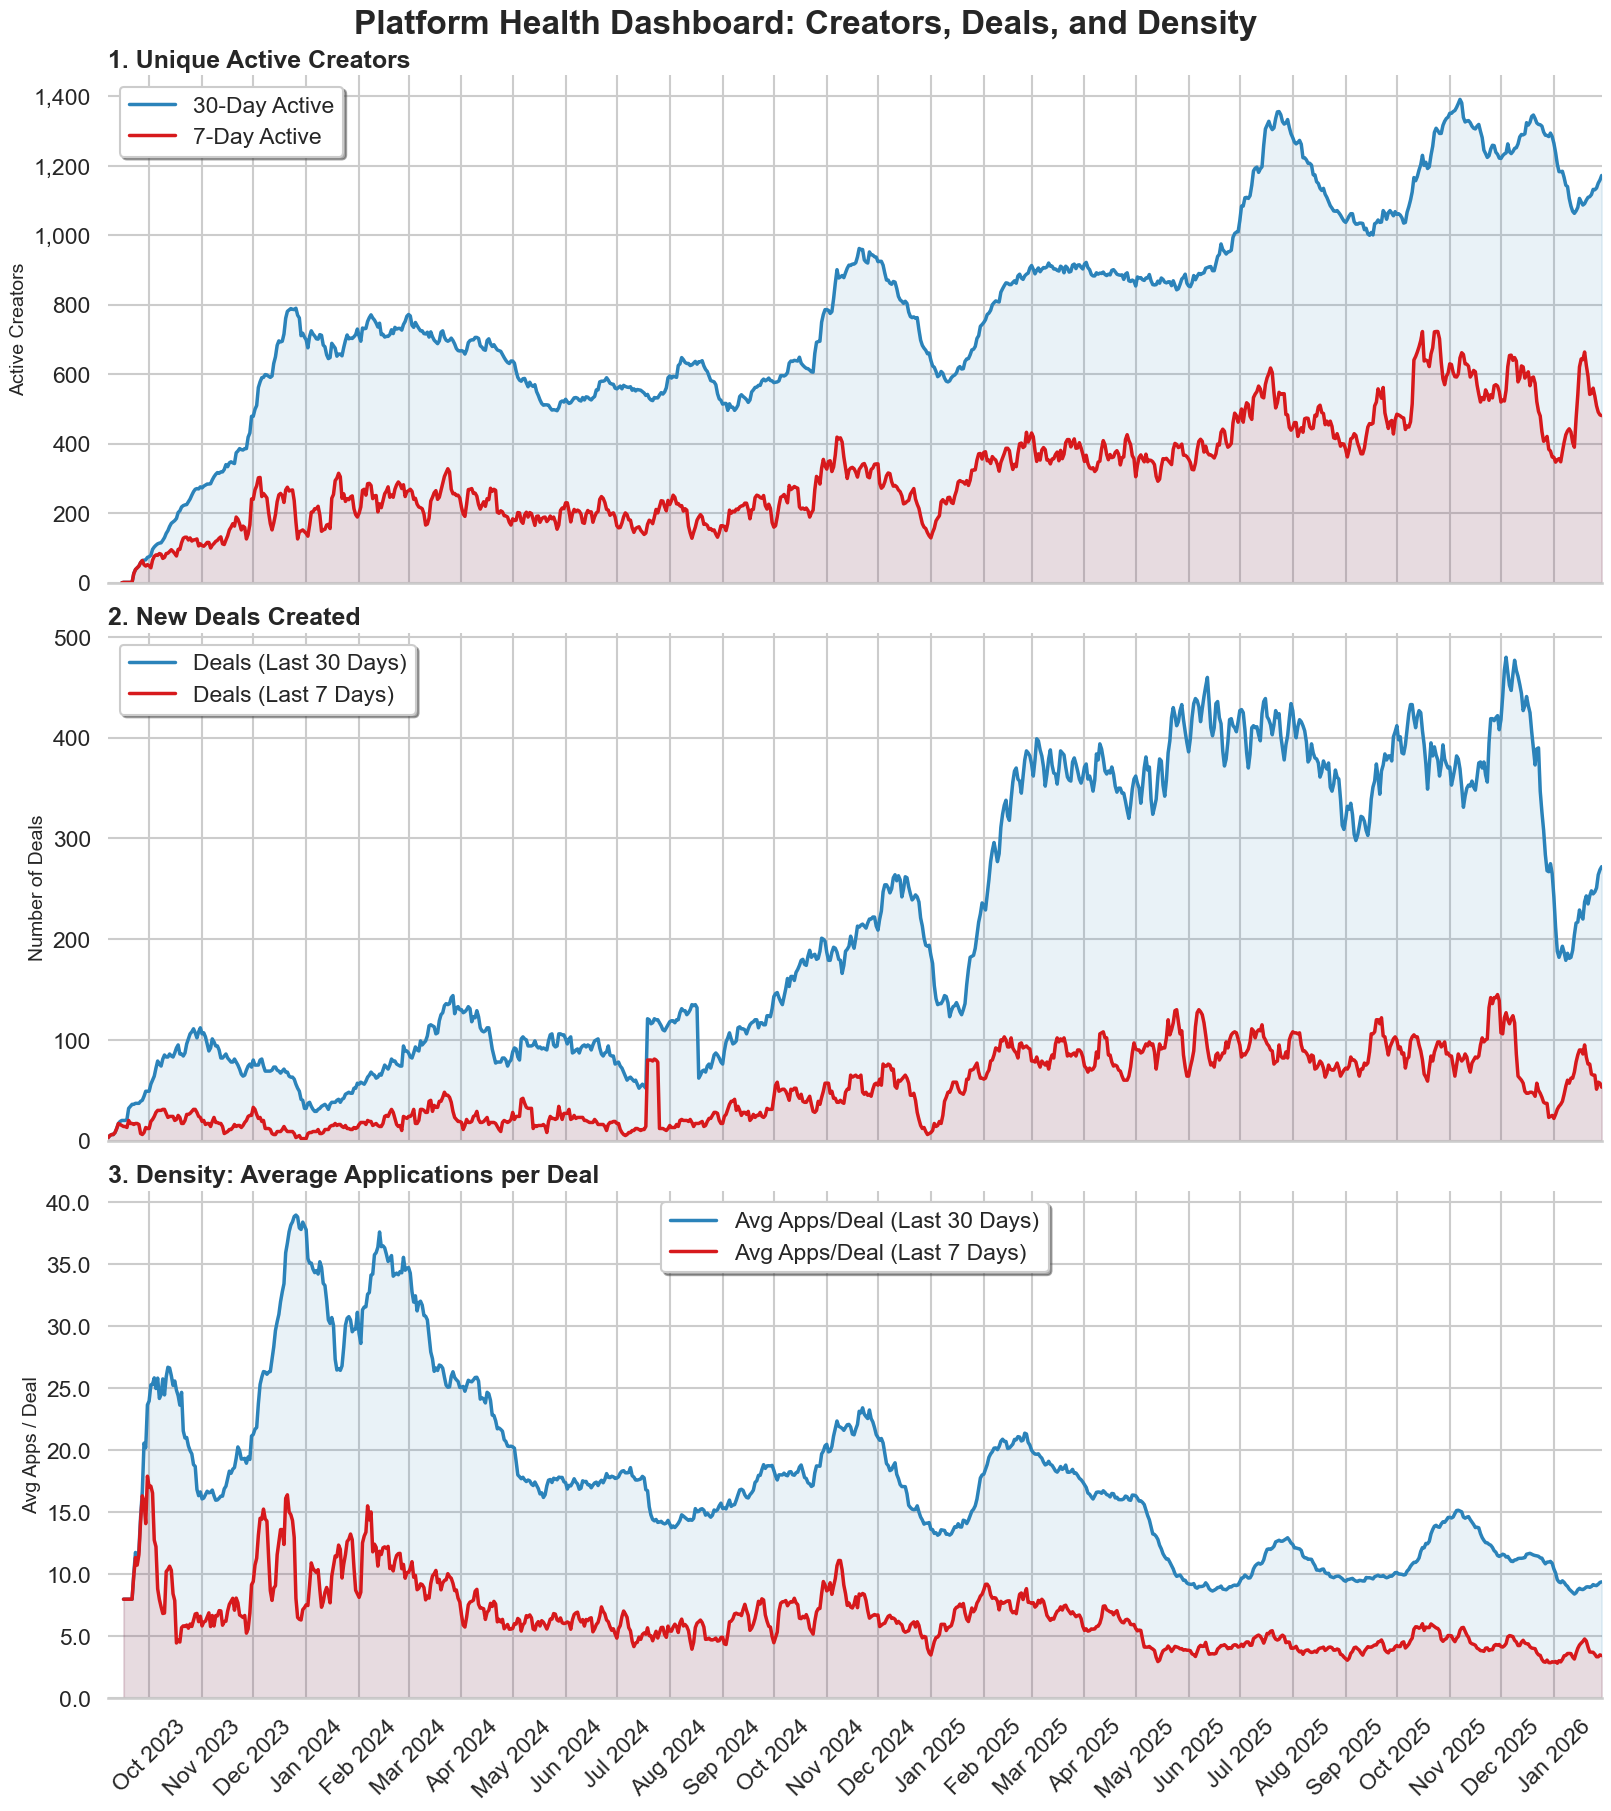

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates

# Set the modern theme
sns.set_theme(style="whitegrid", context="talk")

# Create a figure with 3 rows and 1 column, sharing the X-axis
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(16, 18), sharex=True, layout='constrained')

fig.suptitle('Platform Health Dashboard: Creators, Deals, and Density', 
             fontsize=24, fontweight='bold')

# ==========================================
# PANEL 1: Unique Active Creators
# ==========================================
ax1.plot(df_active_creators['date'], df_active_creators['active_last_month'], 
         label='30-Day Active', color='#2b83ba', linewidth=2.5)
ax1.plot(df_active_creators['date'], df_active_creators['active_last_week'], 
         label='7-Day Active', color='#d7191c', linewidth=2.5)

ax1.fill_between(df_active_creators['date'], df_active_creators['active_last_month'], color='#2b83ba', alpha=0.1)
ax1.fill_between(df_active_creators['date'], df_active_creators['active_last_week'], color='#d7191c', alpha=0.1)

ax1.set_title('1. Unique Active Creators', fontsize=18, fontweight='bold', loc='left')
ax1.set_ylabel('Active Creators', fontsize=14)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))
ax1.legend(loc='upper left', frameon=True, shadow=True)

# ==========================================
# PANEL 2: Rolling Volume of New Deals
# ==========================================
ax2.plot(df_deals_plot['date'], df_deals_plot['deals_last_month'], 
         label='Deals (Last 30 Days)', color='#2b83ba', linewidth=2.5)
ax2.plot(df_deals_plot['date'], df_deals_plot['deals_last_week'], 
         label='Deals (Last 7 Days)', color='#d7191c', linewidth=2.5)

ax2.fill_between(df_deals_plot['date'], df_deals_plot['deals_last_month'], color='#2b83ba', alpha=0.1)
ax2.fill_between(df_deals_plot['date'], df_deals_plot['deals_last_week'], color='#d7191c', alpha=0.1)

ax2.set_title('2. New Deals Created', fontsize=18, fontweight='bold', loc='left')
ax2.set_ylabel('Number of Deals', fontsize=14)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))
ax2.legend(loc='upper left', frameon=True, shadow=True)

# ==========================================
# PANEL 3: Average Applications Per Deal
# ==========================================


# Normalized
ax3.plot(df_rolling_plot['date'], df_rolling_plot['avg_apps_last_month'], 
         label='Avg Apps/Deal (Last 30 Days)', color='#2b83ba', linewidth=2.5)
ax3.plot(df_rolling_plot['date'], df_rolling_plot['avg_apps_last_week'], 
         label='Avg Apps/Deal (Last 7 Days)', color='#d7191c', linewidth=2.5)

ax3.fill_between(df_rolling_plot['date'], df_rolling_plot['avg_apps_last_month'], color='#2b83ba', alpha=0.1)
ax3.fill_between(df_rolling_plot['date'], df_rolling_plot['avg_apps_last_week'], color='#d7191c', alpha=0.1)




ax3.set_title('3. Density: Average Applications per Deal', fontsize=18, fontweight='bold', loc='left')
ax3.set_ylabel('Avg Apps / Deal', fontsize=14)
ax3.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:.1f}'))
ax3.legend(loc='upper center', frameon=True, shadow=True)

# ==========================================
# GLOBAL FORMATTING
# ==========================================
for ax in [ax1, ax2, ax3]:
    ax.set_ylim(bottom=0)
    ax.margins(x=0) # Keeps the lines glued to the edges of the plot
    sns.despine(ax=ax, left=True, bottom=False)

# Date formatting only on the bottom axis
ax3.xaxis.set_major_locator(mdates.MonthLocator())        
ax3.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y')) 
ax3.tick_params(axis='x', rotation=45)

plt.show()

### Active users by category

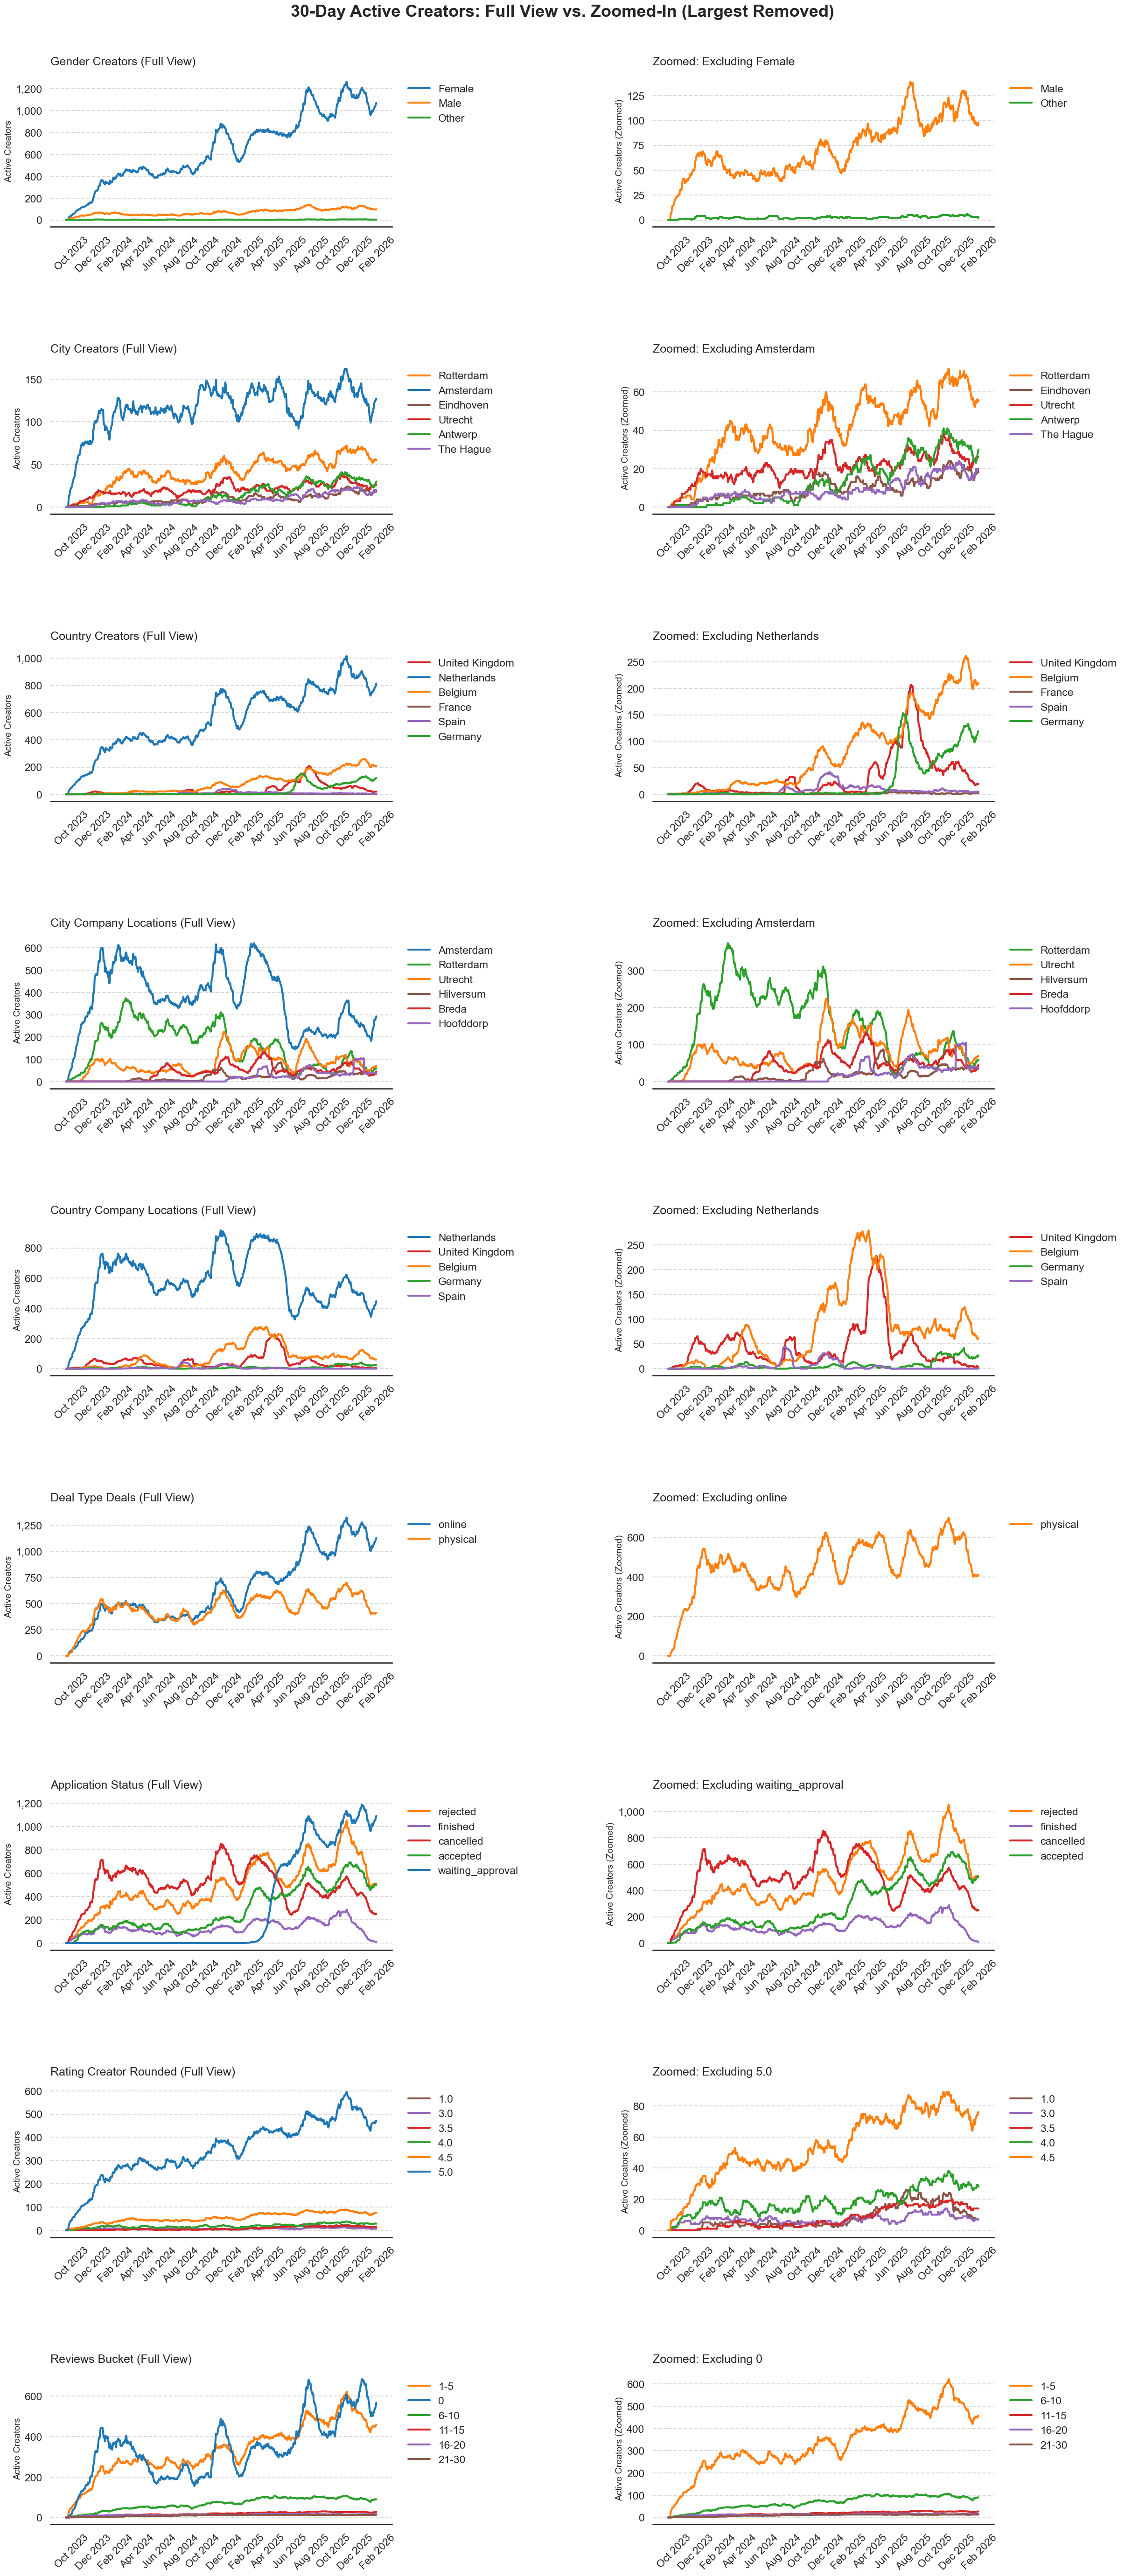

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates

# Ensure datetime setup
df_master_long['date'] = pd.to_datetime(df_master_long['date'])

# 1. Identify unique categories
categories = df_master_long['category'].unique()
n_cats = len(categories)

# 2. Setup theme & figure
sns.set_theme(style="white", context="talk")
fig = plt.figure(figsize=(24, 6 * n_cats), layout="constrained")

fig.suptitle('30-Day Active Creators: Full View vs. Zoomed-In (Largest Removed)', 
             fontsize=26, fontweight='bold', y=1.02)

grid = fig.add_gridspec(n_cats, 2, wspace=0.15, hspace=0.25)

# 3. Loop through categories
for i, cat in enumerate(categories):
    df_cat = df_master_long[df_master_long['category'] == cat].copy()
    
    # Identify top 6 values
    latest_date = df_cat['date'].max()
    top_vals_ranking = df_cat[df_cat['date'] == latest_date].nlargest(6, 'active_last_month')
    
    if top_vals_ranking.empty:
        continue
        
    top_6_vals = top_vals_ranking['value'].tolist()
    largest_group = top_6_vals[0]
    sub_groups = top_6_vals[1:]
    
    # ==========================================
    # COLOR MAPPING: Lock colors to values
    # ==========================================
    # We grab a standard palette and map it specifically to these strings
    standard_palette = sns.color_palette("tab10", len(top_6_vals))
    color_map = dict(zip(top_6_vals, standard_palette))
    
    clean_title = str(cat).replace('_', ' ').title()

    # ==========================================
    # LEFT PANEL: Regular (All Top 6)
    # ==========================================
    ax_reg = fig.add_subplot(grid[i, 0])
    sns.lineplot(
        data=df_cat[df_cat['value'].isin(top_6_vals)], 
        x='date', y='active_last_month', hue='value',
        palette=color_map, linewidth=3, ax=ax_reg
    )
    ax_reg.set_title(f'{clean_title} (Full View)', fontsize=18, pad=15, loc='left')
    ax_reg.set_ylabel('Active Creators', fontsize=14)
    ax_reg.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))

    # ==========================================
    # RIGHT PANEL: Zoomed (Largest Removed)
    # ==========================================
    ax_zoom = fig.add_subplot(grid[i, 1])
    sns.lineplot(
        data=df_cat[df_cat['value'].isin(sub_groups)], 
        x='date', y='active_last_month', hue='value',
        palette=color_map, linewidth=3, ax=ax_zoom
    )
    ax_zoom.set_title(f'Zoomed: Excluding {largest_group}', fontsize=18, pad=15, loc='left')
    ax_zoom.set_ylabel('Active Creators (Zoomed)', fontsize=14)
    ax_zoom.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))

    # ==========================================
    # GLOBAL FORMATTING
    # ==========================================
    for ax in [ax_reg, ax_zoom]:
        ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
        ax.tick_params(axis='x', rotation=45)
        ax.set_xlabel('') 
        sns.despine(ax=ax, left=True)
        ax.grid(axis='y', linestyle='--', alpha=0.7)
        
        if ax.get_legend():
            # Sort legend to match the color mapping order
            ax.legend(title='', frameon=False, loc='upper left', bbox_to_anchor=(1.02, 1))

plt.show()

In [16]:
df_wide = (df_apps.groupby('creator_id')['application_status']
           .value_counts()
           .unstack(fill_value=0))


df_wide['total'] = df_wide.sum(axis=1)
df_wide['percentage_accepted'] = df_wide['accepted'] / df_wide['total']
df_wide['percentage_finished'] = df_wide['finished'] / df_wide['accepted']
# df_wide.to_csv('creator_application_status_totals.csv')

## Interactive plots

### Platform health: by category

In [17]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import ipywidgets as widgets
from IPython.display import display

# ==========================================
# 1. SETUP WIDGETS & TIMELINE
# ==========================================
cols_to_segment = [
    'gender_creator', 'city_creator', 'country_creator', 
    'city_company_locations', 'country_company_locations',
    'deal_type_deals', 'application_status',
    'rating_creator_rounded', 'reviews_bucket'
]

# Global timeline to keep the X-axis stable
global_start = df_apps_filtered['application_created_at'].min().normalize()
global_end = df_apps_filtered['application_created_at'].max().normalize()
dateranges = pd.date_range(start=global_start, end=global_end, freq='D')
target_dates_ns = dateranges.astype('int64').values

# Dropdowns
dropdown_cat = widgets.Dropdown(
    options=['Platform Total'] + sorted(cols_to_segment), 
    value='Platform Total', 
    description='Segment By:', style={'description_width': 'initial'}
)
dropdown_val = widgets.Dropdown(
    options=['All'], 
    value='All', 
    description='Value:', style={'description_width': 'initial'}, disabled=True
)

def update_val_options(*args):
    selected_cat = dropdown_cat.value
    if selected_cat == 'Platform Total':
        dropdown_val.options = ['All']
        dropdown_val.value = 'All'
        dropdown_val.disabled = True
    else:
        unique_vals = sorted(df_apps_filtered[selected_cat].dropna().astype(str).unique().tolist())
        dropdown_val.options = unique_vals
        dropdown_val.value = unique_vals[0] if unique_vals else None
        dropdown_val.disabled = False

dropdown_cat.observe(update_val_options, 'value')

# ==========================================
# 2. PLOTLY DASHBOARD ENGINE
# ==========================================
def render_plotly_dashboard(cat, val):
    # --- A. FILTER DATA ---
    if cat == 'Platform Total' or val == 'All':
        df_a = df_apps_filtered.copy()
        df_d = df_deals.copy()
        title_suffix = "Overall Platform"
    else:
        df_a = df_apps_filtered[df_apps_filtered[cat].astype(str) == val].copy()
        valid_deal_ids = df_a['deal_id'].unique()
        df_d = df_deals[df_deals['deal_id'].isin(valid_deal_ids)].copy()
        title_suffix = f"{cat.replace('_', ' ').title()} = {val}"

    if df_a.empty:
        print(f"No data available for {title_suffix}.")
        return

    # --- B. CALCULATE FAST METRICS ---
    df_a = df_a.sort_values('application_created_at')
    event_dates = df_a['application_created_at'].astype('int64').values
    creators = df_a['creator_id'].values

    # 1. Creators
    active_7d = np.array(get_daily_uniques(target_dates_ns, event_dates, creators, 7))
    active_30d = np.array(get_daily_uniques(target_dates_ns, event_dates, creators, 30))

    # 2. Deals
    df_d['created_at'] = pd.to_datetime(df_d['created_at']).dt.normalize()
    daily_deals = df_d.groupby('created_at').size().reindex(dateranges, fill_value=0)
    deals_7d = daily_deals.rolling(window=7, min_periods=1).sum().values
    deals_30d = daily_deals.rolling(window=30, min_periods=1).sum().values

    # 3. Supply vs Demand (Creators per Deal)
    # np.where safely handles division by zero by inserting NaN where deals are 0
    with np.errstate(divide='ignore', invalid='ignore'):
        ratio_7d = np.where(deals_7d > 0, active_7d / deals_7d, np.nan)
        ratio_30d = np.where(deals_30d > 0, active_30d / deals_30d, np.nan)

    # --- C. BUILD PLOTLY SUBPLOTS ---
    fig = make_subplots(
        rows=3, cols=1, shared_xaxes=True, vertical_spacing=0.08,
        subplot_titles=(
            '1. Unique Active Creators', 
            '2. New Deals Created', 
            '3. Supply vs Demand: Active Creators per Deal'
        )
    )

    blue_line, blue_fill = '#2b83ba', 'rgba(43, 131, 186, 0.15)'
    red_line, red_fill = '#d7191c', 'rgba(215, 25, 28, 0.15)'

    def add_trace_pair(row, y_30, y_7, show_leg=False):
        fig.add_trace(go.Scatter(
            x=dateranges, y=y_30, name='30-Day Metric', mode='lines',
            line=dict(color=blue_line, width=3), fill='tozeroy', fillcolor=blue_fill,
            showlegend=show_leg, legendgroup='30D'
        ), row=row, col=1)
        
        fig.add_trace(go.Scatter(
            x=dateranges, y=y_7, name='7-Day Metric', mode='lines',
            line=dict(color=red_line, width=3), fill='tozeroy', fillcolor=red_fill,
            showlegend=show_leg, legendgroup='7D'
        ), row=row, col=1)

    # Add data to panels 
    add_trace_pair(1, active_30d, active_7d, show_leg=True)
    add_trace_pair(2, deals_30d, deals_7d)
    add_trace_pair(3, ratio_30d, ratio_7d)

    # --- D. GLOBAL FORMATTING ---
    fig.update_layout(
        title=f"<b>Platform Health Dashboard</b><br><sup>{title_suffix}</sup>",
        height=900,
        hovermode="x unified", 
        template="plotly_white",
        legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1),
        margin=dict(t=120, b=40, l=40, r=40)
    )

    fig.update_yaxes(rangemode="tozero")
    # Tweak the formatting for the bottom panel's ratio values to 1 decimal place
    fig.update_yaxes(tickformat=".1f", row=3, col=1) 
    fig.update_xaxes(tickformat="%b %Y", dtick="M1", row=3, col=1)

    fig.show()

# ==========================================
# 3. RENDER UI
# ==========================================
ui = widgets.HBox([dropdown_cat, dropdown_val])
out = widgets.interactive_output(render_plotly_dashboard, {'cat': dropdown_cat, 'val': dropdown_val})

display(ui, out)

Output()

### Quadrant plot: active creators per deal, by category

How to Read Your Quadrants (The Action Plan)

When you run this code, the red dashed lines will cut your chart into four boxes. Here is exactly what you tell your team based on where a bubble (e.g., "Germany" or "France") lands:

- Top-Right (High Volume, High Competition): The War Zones. These markets have tons of deals, but too many creators competing for them. Action: Your sales team needs to prioritize sourcing new deals here immediately, or creators will churn from frustration.

- Bottom-Right (High Volume, Low Competition): The Gold Mines. These are your healthiest markets. You have plenty of deals, and a very healthy, manageable ratio of creators. Brands get variety, creators get work. Action: Scale and invest marketing dollars here.

- Top-Left (Low Volume, High Competition): The Bottlenecks. There are almost no deals here, but a massive surplus of creators waiting for them. Action: Stop spending money acquiring creators in this segment; focus 100% on B2B brand acquisition.

- Bottom-Left (Low Volume, Low Competition): The Ghost Towns. Emerging or dead markets. Low deals, low creators. Action: Ignore these until the core markets are stabilized, or run targeted dual-sided growth experiments.

In [18]:
import pandas as pd
import plotly.express as px

def plot_marketplace_quadrants(segment_col, min_deals=3):
    """
    Plots a quadrant scatter matrix to identify over-saturated vs under-supplied markets.
    min_deals filters out tiny segments (like a country with only 1 deal) to remove noise.
    """
    # 1. Define the "Current" 30-Day Window
    latest_date = df_apps_filtered['application_created_at'].max()
    l30_start = latest_date - pd.Timedelta(days=30)

    # 2. Filter data to just the last 30 days
    df_l30 = df_apps_filtered[df_apps_filtered['application_created_at'] >= l30_start]

    # 3. Calculate metrics per segment
    df_scatter = df_l30.groupby(segment_col).agg(
        active_creators=('creator_id', 'nunique'),
        unique_deals=('deal_id', 'nunique')
    ).reset_index()

    # Calculate the crucial ratio
    df_scatter['creators_per_deal'] = df_scatter['active_creators'] / df_scatter['unique_deals']

    # Filter out statistical noise (e.g., 1 deal with 100 apps throws off the scale)
    df_scatter = df_scatter[df_scatter['unique_deals'] >= min_deals].copy()

    if df_scatter.empty:
        print(f"Not enough data in the last 30 days to plot {segment_col}.")
        return

    # 4. Find the Medians to draw our Quadrants
    med_deals = df_scatter['unique_deals'].median()
    med_ratio = df_scatter['creators_per_deal'].median()

    # ==========================================
    # 5. BUILD THE PLOTLY INTERACTIVE CHART
    # ==========================================
    clean_title = segment_col.replace('_', ' ').title()
    
    fig = px.scatter(
        df_scatter,
        x='unique_deals',
        y='creators_per_deal',
        size='active_creators', # Bubble size represents total creator footprint
        color=segment_col,      # Distinct colors for each segment
        hover_name=segment_col,
        text=segment_col,       # Puts the name right next to the bubble
        title=f"Marketplace Balance (Last 30 Days): By {clean_title}",
        labels={
            'unique_deals': 'Available Deals (Supply Volume)',
            'creators_per_deal': 'Active Creators per Deal (Competition Level)'
        },
        template='plotly_white',
        height=700
    )

    # Add the Quadrant Crosshairs
    fig.add_hline(y=med_ratio, line_dash="dash", line_color="red", opacity=0.5)
    fig.add_vline(x=med_deals, line_dash="dash", line_color="red", opacity=0.5)

    # Clean up aesthetics
    fig.update_traces(textposition='top center', marker=dict(line=dict(width=1, color='DarkSlateGrey')))
    fig.update_layout(showlegend=False) # Hide legend since labels are on the bubbles
    
    # Start axes at 0
    fig.update_xaxes(rangemode="tozero")
    fig.update_yaxes(rangemode="tozero")

    fig.show()

# Run it for your countries
plot_marketplace_quadrants('country_company_locations', min_deals=10)

------

In [19]:
import ipywidgets as widgets
from IPython.display import display

# ==========================================
# 1. THE TIME-SERIES TAB (From earlier)
# ==========================================
# (Assuming dropdown_cat, dropdown_val, and render_plotly_dashboard are already defined in memory)
tab1_ui = widgets.HBox([dropdown_cat, dropdown_val])
tab1_out = widgets.interactive_output(render_plotly_dashboard, {'cat': dropdown_cat, 'val': dropdown_val})
tab1_layout = widgets.VBox([
    widgets.HTML("<h2>Platform Health Over Time</h2><p>Select a segment to view rolling 30-day and 7-day metrics.</p>"),
    tab1_ui, 
    tab1_out
])

# ==========================================
# 2. THE QUADRANT SCATTER TAB
# ==========================================
# Create a dropdown to select which column to use for the scatter plot
dropdown_scatter = widgets.Dropdown(
    options=[c for c in cols_to_segment if 'reviews' not in c and 'status' not in c], # Filter out non-location/type categories
    value='country_company_locations',
    description='Analyze:',
    style={'description_width': 'initial'}
)

# Wrap the scatter plot function so it renders inside a widget output area
def render_scatter_tab(segment_col):
    plot_marketplace_quadrants(segment_col, min_deals=3)

tab2_out = widgets.interactive_output(render_scatter_tab, {'segment_col': dropdown_scatter})
tab2_layout = widgets.VBox([
    widgets.HTML("<h2>Marketplace Balance (Last 30 Days)</h2><p>Identify over-saturated vs. under-supplied markets.</p>"),
    dropdown_scatter, 
    tab2_out
])

# ==========================================
# 3. BUILD THE TABBED APP INTERFACE
# ==========================================
# Create the Tab widget
app_tabs = widgets.Tab(children=[tab1_layout, tab2_layout])

# Name the tabs
app_tabs.set_title(0, '📈 Rolling Health Dashboard')
app_tabs.set_title(1, '🎯 Market Saturation Matrix')

# Display the final application
display(app_tabs)

# Deals 

Comments
- Starts at 2025-01-01, since we have a lot of missingness in creator locations before that (necessary for spacial features)

In [20]:
df_deals

,applicants_applications_count,content_types,deal_id,main_image,min_social_media_followers,deal_tags,live_since,first_application_at,last_application_at,company_locations,...,text_word_count,title_word_count,company_location_id,apps_after_7_days,online_eligible_last_week,online_eligible_last_month,physical_active_creators_7d_50km,physical_active_creators_30d_50km,global_active_last_month,global_active_last_week
0,48,"[{'id': 21, 'name': 'Fashion', 'slug': 'Dress'}]",019689e2-1a1f-00c8-81a2-3615a353cd8a,uploads/deals/019689e2-1a92-ffff-a0eb-541b6d69...,50000,None,2023-09-07 09:48:51.484123,2023-09-21 07:03:29.872132,2023-11-14 13:49:25.049111,None,...,117,3,019bb11c-a564-015f-0589-70719678b33b,0,0.0,0.0,0,0,NaN,NaN
1,0,"[{'id': 39, 'name': 'Experiences', 'slug': 'Te...",019689e2-20d4-00c8-4ceb-afb69afa57dc,uploads/deals/019689e2-22bf-ffff-2928-8defbeb7...,2500,None,2023-09-07 10:59:58.899412,NaT,NaT,"[{""id"": ""01KERHT9V405FZ6ENY98QN966E"", ""name"": ...",...,56,9,<NA>,0,0.0,0.0,0,0,NaN,NaN
2,11,"[{'id': 39, 'name': 'Experiences', 'slug': 'Te...",019689e2-23f5-00c8-7750-d15e1f1a744c,uploads/deals/019689e2-2455-ffff-5cf8-c43410f2...,2500,None,2023-09-07 11:00:41.904181,2023-09-21 10:28:27.631503,2023-10-21 12:33:21.687587,"[{""id"": ""01KERHT9V405FZ6ENY98QN966E"", ""name"": ...",...,56,9,019bb11d-2764-015f-f33a-be4a2f5498ce,0,0.0,0.0,0,0,NaN,NaN
3,94,"[{'id': 21, 'name': 'Fashion', 'slug': 'Dress'}]",019689e2-2c11-00c8-f8af-acf5689b167d,uploads/deals/019689e2-2c72-ffff-cd7f-96378b9e...,50000,None,2023-09-08 07:58:15.205196,2023-09-24 12:19:34.069689,2023-11-20 14:17:29.180717,None,...,117,3,019bb11c-a564-015f-0589-70719678b33b,0,0.0,0.0,0,0,NaN,NaN
4,95,"[{'id': 21, 'name': 'Fashion', 'slug': 'Dress'}]",019689e2-2e21-00c8-a03d-e9a97e2a0245,uploads/deals/019689e2-2ec9-ffff-64be-c11c16f5...,50000,None,2023-09-08 08:02:29.330473,2023-09-15 12:42:26.000081,2023-11-15 11:56:08.045898,None,...,117,3,019bb11c-a564-015f-0589-70719678b33b,1,0.0,0.0,0,0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6421,2,"[{'id': 37, 'name': 'Luxury', 'slug': 'Sketch-...",019c0aae-7090-00c8-5762-1d38ffd4feb4,uploads/deals/019c0ab2-c92d-ffff-7896-1fd6c0d2...,25000,None,2026-01-29 16:55:42.095718,2026-01-29 17:51:40.493538,2026-01-29 20:14:08.449596,None,...,1,8,<NA>,2,487.0,1029.0,0,0,1178.0,550.0
6422,1,"[{'id': 37, 'name': 'Luxury', 'slug': 'Sketch-...",019c0abc-3116-00c8-409a-3b458492e415,uploads/deals/019c0abf-d07a-ffff-7fc1-6fb34172...,1500,None,2026-01-29 17:10:31.560233,2026-01-29 21:05:01.213681,2026-01-29 21:05:01.213681,None,...,1,4,<NA>,1,54.0,119.0,0,0,1178.0,550.0
6423,2,"[{'id': 39, 'name': 'Experiences', 'slug': 'Te...",019c0b54-a139-00c8-6c0f-67d89c75632c,uploads/deals/019c0b58-380f-ffff-4d40-98dd9764...,1500,None,2026-01-29 20:01:14.400677,2026-01-29 21:05:15.863441,2026-01-30 06:19:24.501434,None,...,1,5,<NA>,2,541.0,1148.0,0,0,1178.0,550.0
6424,25,"[{'id': 39, 'name': 'Experiences', 'slug': 'Te...",019c0b5a-464e-00c8-762c-376fc87682da,uploads/deals/019c0b5b-a1a5-ffff-481e-2544725d...,5000,None,2026-01-29 20:05:04.885661,2026-01-29 20:12:56.888284,2026-01-30 06:55:05.359563,None,...,1,6,<NA>,25,541.0,1148.0,0,0,1178.0,550.0


In [21]:
import pandas as pd
import numpy as np

# ==========================================
# 1. CORE DATA PREPARATION (Deal-Level)
# ==========================================
# Filter out dead deals and missing data

start_at_date_col = 'created_at'

df_clean = df_deals.dropna(subset=[start_at_date_col, 'apps_after_7_days', 'deal_type']).copy()

# Establish the 7-Day Cohort Evaluation Date
df_clean[start_at_date_col] = pd.to_datetime(df_clean[start_at_date_col])
df_clean['evaluation_date'] = (df_clean[start_at_date_col] + pd.Timedelta(days=7)).dt.normalize()

# Dynamically assign the "Eligible Supply"
df_clean['eligible_supply'] = np.where(
    df_clean['deal_type'] == 'physical',
    df_clean['physical_active_creators_7d_50km'],
    df_clean['online_eligible_last_week']
)

# Protect against Zero-Division
df_clean['eligible_supply'] = df_clean['eligible_supply'].replace(0, np.nan)

# Calculate the per-deal capture rate (Optional, but good for debugging outliers)
df_clean['deal_capture_rate_pct'] = (df_clean['apps_after_7_days'] / df_clean['eligible_supply']) * 100

# Filter for relevant timeframe before aggregating to save memory
df_clean = df_clean[df_clean['evaluation_date'] >= "2024-01-01"]

# ==========================================
# 2. THE DYNAMIC AGGREGATION FUNCTION
# ==========================================
def get_aggregated_metrics(df, freq='W'):
    """
    Groups deal performance by deal_type and time frequency.
    freq='W' (Weekly) or freq='ME' (Month-End).
    """
    # pd.Grouper is the pro way to group by time without setting the date as an index
    grouped = df.groupby(['deal_type', pd.Grouper(key='evaluation_date', freq=freq)])
    
    df_agg = grouped.agg(
        deals_launched=('deal_id', 'nunique'),
        total_apps=('apps_after_7_days', 'sum'),
        total_supply=('eligible_supply', 'sum'),
        avg_7d_apps=('apps_after_7_days', 'mean'),             # Metric 1: Launch Momentum
        median_deal_rate=('deal_capture_rate_pct', 'median')   # Just for your internal checks
    ).reset_index()
    
    # Metric 2: True Weighted Capture Rate (The outlier killer)
    # Total Demand / Total Supply across the whole period
    df_agg['weighted_capture_rate'] = (df_agg['total_apps'] / df_agg['total_supply']) * 100
    
    # Clean up any potential inf/nan from weeks with 0 supply
    df_agg['weighted_capture_rate'] = df_agg['weighted_capture_rate'].replace([np.inf, -np.inf], np.nan)
    
    # Drop periods that had 0 deals launched to keep the plot lines clean
    df_agg = df_agg[df_agg['deals_launched'] > 0]
    
    return df_agg

# ==========================================
# 3. GENERATE YOUR DASHBOARD DATAFRAMES
# ==========================================
# For a weekly view (W-MON means the week starts on Monday)
df_weekly_metrics = get_aggregated_metrics(df_clean, freq='W-MON')
# df_weekly_metrics = df_weekly_metrics[df_weekly_metrics.evaluation_date < df_deals.created_at.max()]

# Or, if the C-Suite prefers a 30,000-foot view (Monthly End)
df_monthly_metrics = get_aggregated_metrics(df_clean, freq='ME')
df_monthly_metrics = df_monthly_metrics[df_monthly_metrics.evaluation_date < df_deals.created_at.max()]


In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates

def plot_performance_metrics(df_metrics):

    # Set the modern theme
    sns.set_theme(style="whitegrid", context="talk")

#     # Create a figure with 2 rows and 1 column, sharing the X-axis
#     fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 12), sharex=True, layout='constrained')

#     fig.suptitle('Deal Performance: Launch Momentum vs. Liquidity', 
#                 fontsize=24, fontweight='bold')
    
    # Create a figure with 2 rows and 1 column, sharing the X-axis
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 9), sharex=True, layout='constrained')

    fig.suptitle('Deal Performance: Launch Momentum vs. Liquidity', 
                fontsize=24, fontweight='bold')

    # Separate the dataframe into Online and Physical for easier plotting
    df_online = df_metrics[df_metrics['deal_type'] == 'online']
    df_physical = df_metrics[df_metrics['deal_type'] == 'physical']

    # ==========================================
    # PANEL 1: 7-Day Launch Momentum (Volume)
    # ==========================================
    # Swapped 'smoothed_apps' for 'avg_7d_apps'
    ax1.plot(df_online['evaluation_date'], df_online['avg_7d_apps'], 
            label='Online Deals', color='#2b83ba', linewidth=2.5)
    ax1.plot(df_physical['evaluation_date'], df_physical['avg_7d_apps'], 
            label='Physical Deals', color='#d7191c', linewidth=2.5)

    ax1.fill_between(df_online['evaluation_date'], df_online['avg_7d_apps'], color='#2b83ba', alpha=0.1)
    ax1.fill_between(df_physical['evaluation_date'], df_physical['avg_7d_apps'], color='#d7191c', alpha=0.1)

    ax1.set_title('1. 7-Day Launch Momentum (Avg Applications per Deal)', fontsize=18, fontweight='bold', loc='left')
    ax1.set_ylabel('Avg Apps (7 Days)', fontsize=14)
    ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))
    ax1.legend(loc='upper left', frameon=True, shadow=True)

    # ==========================================
    # PANEL 2: Supply vs. Demand Penetration (Efficiency)
    # ==========================================
    # Swapped 'smoothed_capture_rate' for 'weighted_capture_rate'
    ax2.plot(df_online['evaluation_date'], df_online['weighted_capture_rate'], 
            label='Online Deals', color='#2b83ba', linewidth=2.5)
    ax2.plot(df_physical['evaluation_date'], df_physical['weighted_capture_rate'], 
            label='Physical Deals', color='#d7191c', linewidth=2.5)

    ax2.fill_between(df_online['evaluation_date'], df_online['weighted_capture_rate'], color='#2b83ba', alpha=0.1)
    ax2.fill_between(df_physical['evaluation_date'], df_physical['weighted_capture_rate'], color='#d7191c', alpha=0.1)

    ax2.set_title('2. Supply vs. Demand Penetration (Weighted Capture Rate %)', fontsize=18, fontweight='bold', loc='left')
    ax2.set_ylabel('Capture Rate (%)', fontsize=14)
    # Formatted cleanly as percentages (e.g. 15.0%)
    ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:.1f}%'))
    ax2.legend(loc='upper left', frameon=True, shadow=True)

    # ==========================================
    # GLOBAL FORMATTING
    # ==========================================
    for ax in [ax1, ax2]:
        ax.set_ylim(bottom=0)
        ax.margins(x=0) 
        sns.despine(ax=ax, left=True, bottom=False)

    ax2.xaxis.set_major_locator(mdates.MonthLocator())        
    ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y')) 
    ax2.tick_params(axis='x', rotation=45)

    # Save for your slide deck
    # plt.savefig('deal_performance_dashboard.png', dpi=300, bbox_inches='tight')
    plt.show()

# Run it by passing in your aggregated dataframe:
# plot_performance_metrics(df_weekly_metrics)

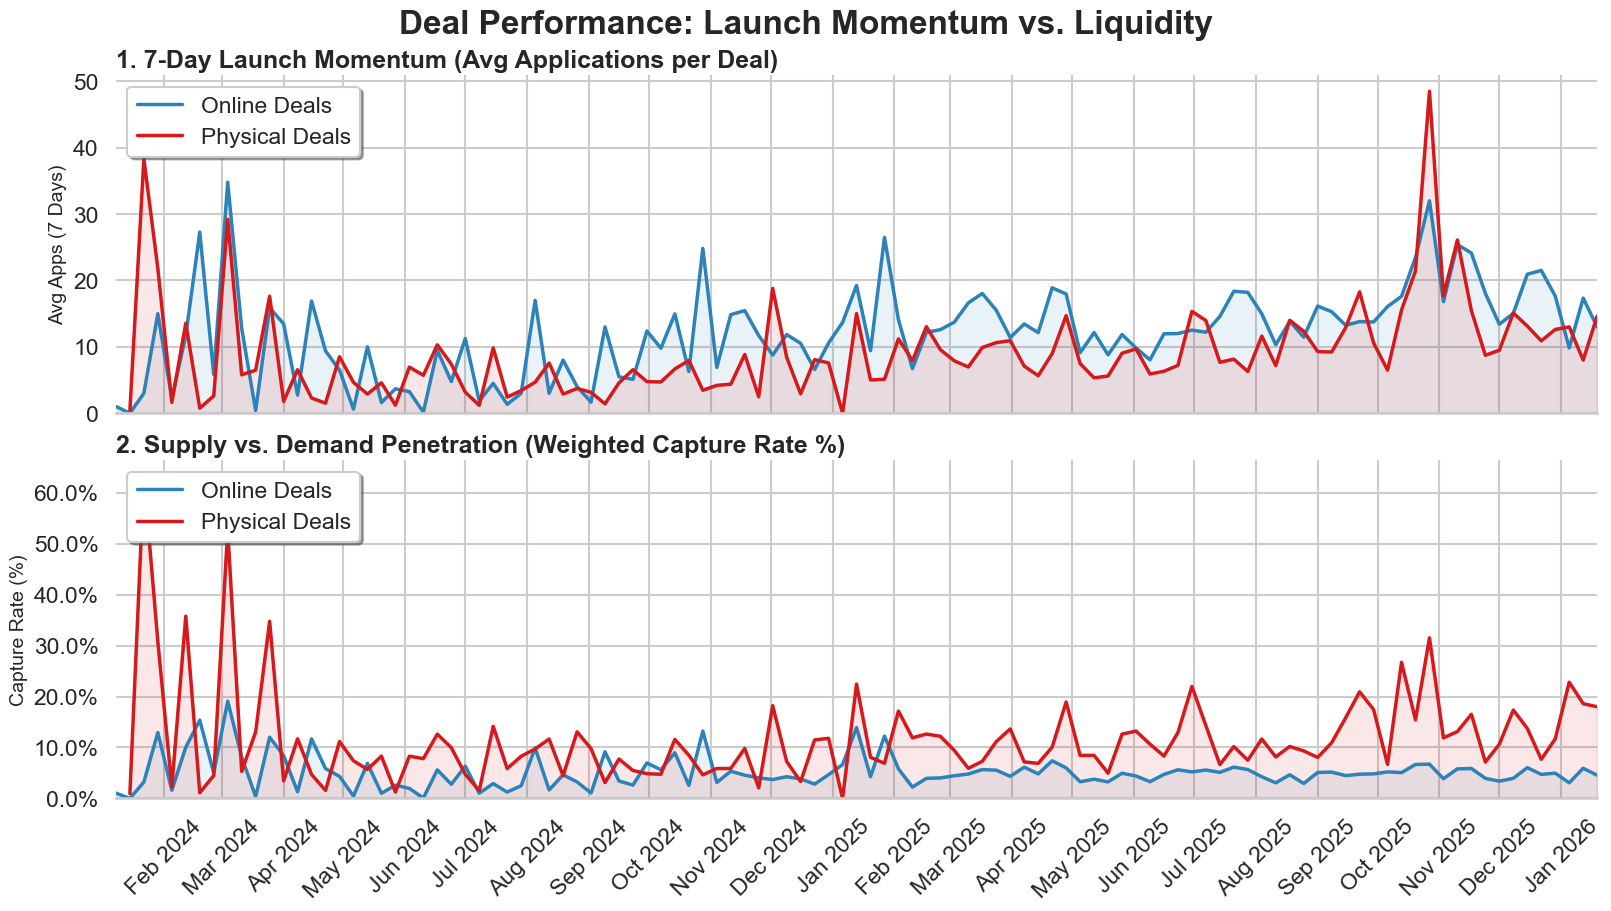

In [23]:
plot_performance_metrics(df_weekly_metrics[df_weekly_metrics.evaluation_date < "2026-01-26"])

In [24]:
df_weekly_metrics.groupby('deal_type')['weighted_capture_rate'].mean()

deal_type
online       5.118042
physical    11.409814
Name: weighted_capture_rate, dtype: float64

In [25]:
df_weekly_metrics.sort_values('evaluation_date', ascending=False)[:10].groupby('deal_type')['weighted_capture_rate'].mean()

deal_type
online      5.158734
physical    9.151163
Name: weighted_capture_rate, dtype: float64

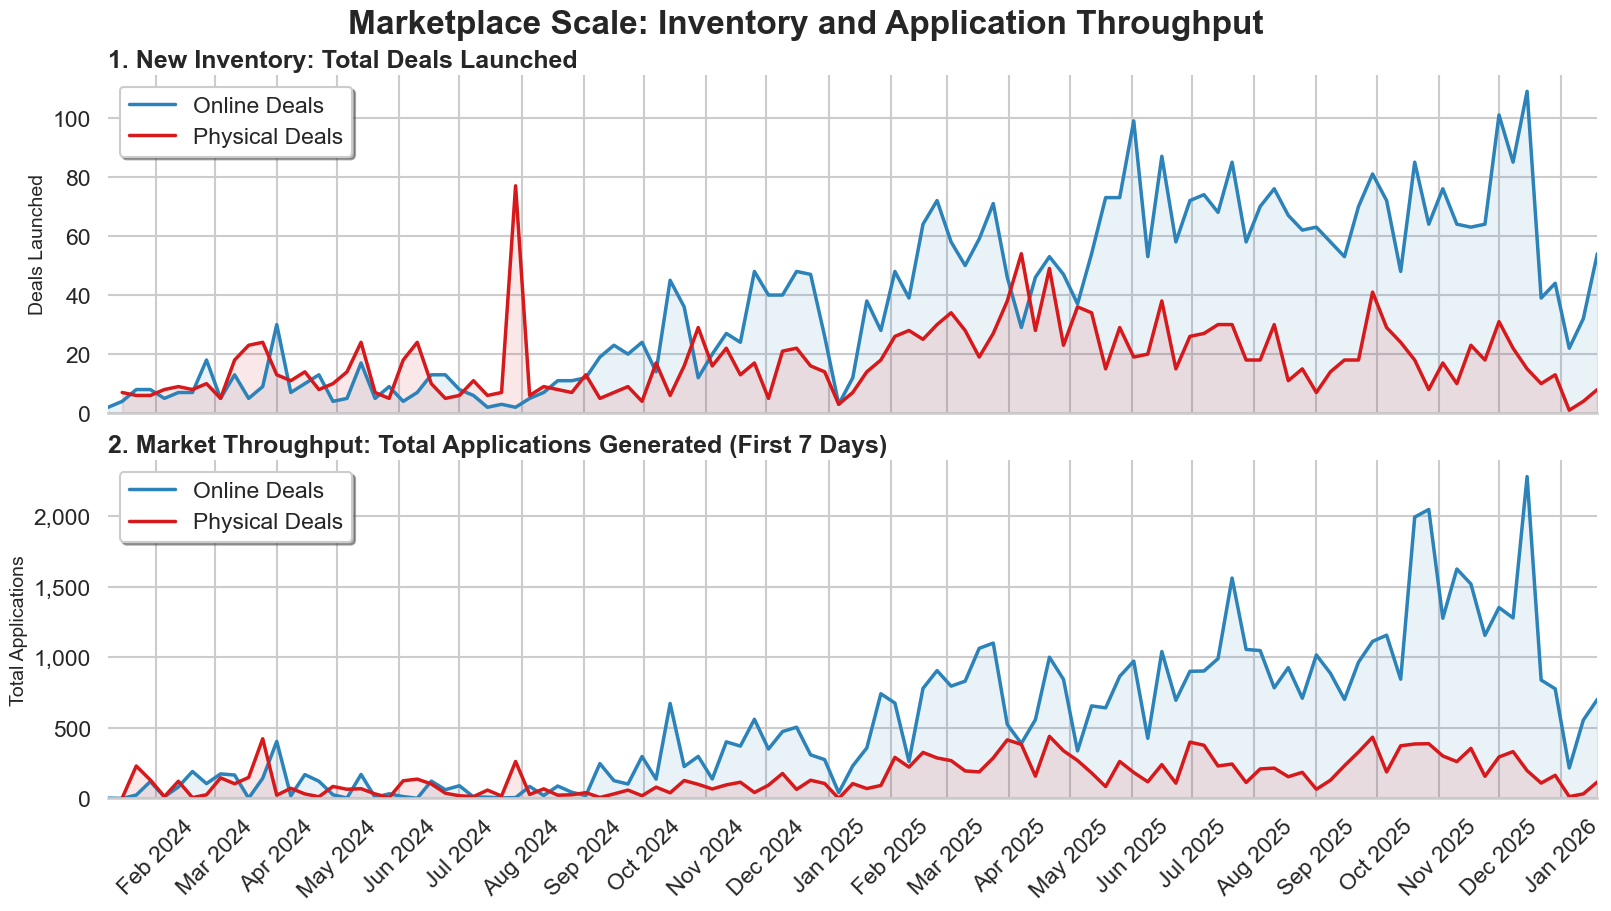

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates

def plot_scale_metrics(df_metrics):

    # Set the modern theme to match the previous slide
    sns.set_theme(style="whitegrid", context="talk")

    # Create a figure with 2 rows and 1 column, sharing the X-axis
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 9), sharex=True, layout='constrained')

    fig.suptitle('Marketplace Scale: Inventory and Application Throughput', 
                fontsize=24, fontweight='bold')

    # Separate the dataframe into Online and Physical
    df_online = df_metrics[df_metrics['deal_type'] == 'online']
    df_physical = df_metrics[df_metrics['deal_type'] == 'physical']

    # ==========================================
    # PANEL 1: Total Deals Launched (Inventory)
    # ==========================================
    ax1.plot(df_online['evaluation_date'], df_online['deals_launched'], 
            label='Online Deals', color='#2b83ba', linewidth=2.5)
    ax1.plot(df_physical['evaluation_date'], df_physical['deals_launched'], 
            label='Physical Deals', color='#d7191c', linewidth=2.5)

    ax1.fill_between(df_online['evaluation_date'], df_online['deals_launched'], color='#2b83ba', alpha=0.1)
    ax1.fill_between(df_physical['evaluation_date'], df_physical['deals_launched'], color='#d7191c', alpha=0.1)

    ax1.set_title('1. New Inventory: Total Deals Launched', fontsize=18, fontweight='bold', loc='left')
    ax1.set_ylabel('Deals Launched', fontsize=14)
    ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))
    ax1.legend(loc='upper left', frameon=True, shadow=True)

    # ==========================================
    # PANEL 2: Total Applications (Throughput)
    # ==========================================
    ax2.plot(df_online['evaluation_date'], df_online['total_apps'], 
            label='Online Deals', color='#2b83ba', linewidth=2.5)
    ax2.plot(df_physical['evaluation_date'], df_physical['total_apps'], 
            label='Physical Deals', color='#d7191c', linewidth=2.5)

    ax2.fill_between(df_online['evaluation_date'], df_online['total_apps'], color='#2b83ba', alpha=0.1)
    ax2.fill_between(df_physical['evaluation_date'], df_physical['total_apps'], color='#d7191c', alpha=0.1)

    ax2.set_title('2. Market Throughput: Total Applications Generated (First 7 Days)', fontsize=18, fontweight='bold', loc='left')
    ax2.set_ylabel('Total Applications', fontsize=14)
    ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))
    ax2.legend(loc='upper left', frameon=True, shadow=True)

    # ==========================================
    # GLOBAL FORMATTING
    # ==========================================
    for ax in [ax1, ax2]:
        ax.set_ylim(bottom=0)
        ax.margins(x=0) 
        sns.despine(ax=ax, left=True, bottom=False)

    ax2.xaxis.set_major_locator(mdates.MonthLocator())        
    ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y')) 
    ax2.tick_params(axis='x', rotation=45)

    # 2. THE KEYNOTE EXPORT TRICK
    # - dpi=300: Guarantees it looks perfectly crisp on Retina displays.
    # - transparent=True: The ultimate "pro" move. It removes the white background 
    #   so your plot blends seamlessly into your company's slide template (even in dark mode!).
    # - We REMOVED bbox_inches='tight': This forces Matplotlib to strictly 
    #   respect our 16:9 figsize, ensuring it perfectly fills the slide edge-to-edge.
    # plt.savefig('keynote_scale_dashboard.png', dpi=300, transparent=True)
    plt.show()

# Run it by passing in your aggregated dataframe:
plot_scale_metrics(df_weekly_metrics[df_weekly_metrics.evaluation_date < "2026-01-26"])

In [27]:
df_weekly_metrics

,deal_type,evaluation_date,deals_launched,total_apps,total_supply,avg_7d_apps,median_deal_rate,weighted_capture_rate
0,online,2024-01-08,2,2,192.0,1.000,1.086957,1.041667
1,online,2024-01-15,4,0,455.0,0.000,0.000000,0.000000
2,online,2024-01-22,8,24,744.0,3.000,0.000000,3.225806
3,online,2024-01-29,8,120,928.0,15.000,0.000000,12.931034
4,online,2024-02-05,5,11,684.0,2.200,0.909091,1.608187
...,...,...,...,...,...,...,...,...
214,physical,2026-01-12,4,32,172.0,8.000,8.571429,18.604651
215,physical,2026-01-19,8,117,650.0,14.625,20.464908,18.000000
216,physical,2026-01-26,17,0,194.0,0.000,0.000000,0.000000
217,physical,2026-02-02,16,0,203.0,0.000,0.000000,0.000000


In [28]:
df_deals_plot

,date,deals_last_week,deals_last_month,year
2023-09-07,2023-09-07,3.0,3.0,2023
2023-09-08,2023-09-08,5.0,5.0,2023
2023-09-09,2023-09-09,6.0,6.0,2023
2023-09-10,2023-09-10,6.0,6.0,2023
2023-09-11,2023-09-11,8.0,8.0,2023
...,...,...,...,...
2026-01-25,2026-01-25,65.0,247.0,2026
2026-01-26,2026-01-26,51.0,251.0,2026
2026-01-27,2026-01-27,58.0,264.0,2026
2026-01-28,2026-01-28,57.0,269.0,2026


In [29]:
import pandas as pd

# 1. Create a Year column for easy grouping
df_weekly_metrics['year'] = df_weekly_metrics['evaluation_date'].dt.year

# 2. Filter strictly for 2024 and 2025 
df_yoy = df_weekly_metrics[df_weekly_metrics['year'].isin([2024, 2025])]

# 3. Group by Deal Type and Year, calculating the means you requested
df_summary = df_yoy.groupby(['deal_type', 'year']).agg(
    avg_weekly_volume=('total_apps', 'mean'),  # "On average, how many apps per week?"
    avg_deal_momentum=('avg_7d_apps', 'mean')  # "On average, how many apps does a single deal get?"
).unstack('year') # Unstack pivots the years into side-by-side columns

# 4. Calculate the YoY Percentage Growth for both metrics
# Formula: ((New - Old) / Old) * 100
df_summary[('avg_weekly_volume', 'YoY_Growth_%')] = (
    (df_summary[('avg_weekly_volume', 2025)] - df_summary[('avg_weekly_volume', 2024)]) 
    / df_summary[('avg_weekly_volume', 2024)] * 100
)

df_summary[('avg_deal_momentum', 'YoY_Growth_%')] = (
    (df_summary[('avg_deal_momentum', 2025)] - df_summary[('avg_deal_momentum', 2024)]) 
    / df_summary[('avg_deal_momentum', 2024)] * 100
)

# 5. Clean up the formatting so it's ready to copy-paste into your presentation notes
# Sort columns logically: 2024, 2025, YoY%
df_summary = df_summary.sort_index(axis=1, level=[0, 1], ascending=[True, True])

# Print with clean formatting
pd.options.display.float_format = '{:.1f}'.format
print("=== 2024 vs 2025 Platform Performance ===")
df_summary

=== 2024 vs 2025 Platform Performance ===


avg_deal_momentum                   avg_weekly_volume        \
year                   2024 2025 YoY_Growth_%              2024  2025   
deal_type                                                               
online                  8.8 15.3         74.3             154.6 931.9   
physical                6.9 11.2         63.6              79.6 237.1   

                        
year      YoY_Growth_%  
deal_type               
online           502.7  
physical         197.8

In [30]:
df_weekly_metrics[df_weekly_metrics.evaluation_date > '2024-12-31'].groupby('deal_type')['total_apps'].mean()

deal_type
online     910.0
physical   215.4
Name: total_apps, dtype: float64

In [31]:
df_weekly_metrics[df_weekly_metrics.evaluation_date > '2024-12-31'].groupby('deal_type')['avg_7d_apps'].mean()

deal_type
online     15.3
physical   10.7
Name: avg_7d_apps, dtype: float64

In [32]:
df_weekly_metrics.sort_values('evaluation_date', ascending=False)[:10].groupby('deal_type')['avg_7d_apps'].mean()

deal_type
online     16.6
physical    4.5
Name: avg_7d_apps, dtype: float64

In [33]:
df_weekly_metrics

,deal_type,evaluation_date,deals_launched,total_apps,total_supply,avg_7d_apps,median_deal_rate,weighted_capture_rate,year
0,online,2024-01-08,2,2,192.0,1.0,1.1,1.0,2024
1,online,2024-01-15,4,0,455.0,0.0,0.0,0.0,2024
2,online,2024-01-22,8,24,744.0,3.0,0.0,3.2,2024
3,online,2024-01-29,8,120,928.0,15.0,0.0,12.9,2024
4,online,2024-02-05,5,11,684.0,2.2,0.9,1.6,2024
...,...,...,...,...,...,...,...,...,...
214,physical,2026-01-12,4,32,172.0,8.0,8.6,18.6,2026
215,physical,2026-01-19,8,117,650.0,14.6,20.5,18.0,2026
216,physical,2026-01-26,17,0,194.0,0.0,0.0,0.0,2026
217,physical,2026-02-02,16,0,203.0,0.0,0.0,0.0,2026


# FULL PLOT

In [34]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import ipywidgets as widgets
from IPython.display import display

# ==========================================
# 1. SETUP WIDGETS & TIMELINE
# ==========================================
cols_to_segment = [
    'gender_creator', 'city_creator', 'country_creator', 
    'city_company_locations', 'country_company_locations',
    'deal_type_deals', 'application_status',
    'rating_creator_rounded', 'reviews_bucket'
]

# Global timeline to keep the X-axis stable
global_start = df_apps_filtered['application_created_at'].min().normalize()
global_end = df_apps_filtered['application_created_at'].max().normalize()
dateranges = pd.date_range(start=global_start, end=global_end, freq='D')
target_dates_ns = dateranges.astype('int64').values

# Dropdowns
dropdown_cat = widgets.Dropdown(
    options=['Platform Total'] + sorted(cols_to_segment), 
    value='Platform Total', 
    description='Segment By:', style={'description_width': 'initial'}
)
dropdown_val = widgets.Dropdown(
    options=['All'], 
    value='All', 
    description='Value:', style={'description_width': 'initial'}, disabled=True
)

def update_val_options(*args):
    selected_cat = dropdown_cat.value
    if selected_cat == 'Platform Total':
        dropdown_val.options = ['All']
        dropdown_val.value = 'All'
        dropdown_val.disabled = True
    else:
        unique_vals = sorted(df_apps_filtered[selected_cat].dropna().astype(str).unique().tolist())
        dropdown_val.options = unique_vals
        dropdown_val.value = unique_vals[0] if unique_vals else None
        dropdown_val.disabled = False

dropdown_cat.observe(update_val_options, 'value')

# ==========================================
# 2. PLOTLY DASHBOARD ENGINE
# ==========================================
def render_plotly_dashboard(cat, val):
    # --- A. FILTER DATA ---
    if cat == 'Platform Total' or val == 'All':
        df_a = df_apps_filtered.copy()
        df_d = df_deals.copy()
        title_suffix = "Overall Platform"
    else:
        df_a = df_apps_filtered[df_apps_filtered[cat].astype(str) == val].copy()
        valid_deal_ids = df_a['deal_id'].unique()
        df_d = df_deals[df_deals['deal_id'].isin(valid_deal_ids)].copy()
        title_suffix = f"{cat.replace('_', ' ').title()} = {val}"

    if df_a.empty:
        print(f"No data available for {title_suffix}.")
        return

    # --- B. CALCULATE FAST METRICS ---
    # Sorting is mandatory for the pointer logic!
    df_a = df_a.sort_values('application_created_at')
    
    event_dates = df_a['application_created_at'].astype('int64').values
    creators = df_a['creator_id'].values
    deal_ids = df_a['deal_id'].values # Extracted for Metric 4

    # 1. Creators
    active_7d = np.array(get_daily_uniques(target_dates_ns, event_dates, creators, 7))
    active_30d = np.array(get_daily_uniques(target_dates_ns, event_dates, creators, 30))

    # 2. Deals
    df_d['created_at'] = pd.to_datetime(df_d['created_at']).dt.normalize()
    daily_deals = df_d.groupby('created_at').size().reindex(dateranges, fill_value=0)
    deals_7d = daily_deals.rolling(window=7, min_periods=1).sum().values
    deals_30d = daily_deals.rolling(window=30, min_periods=1).sum().values

    # 3. Supply vs Demand (Creators per Deal)
    # np.where safely handles division by zero by inserting NaN where deals are 0
    with np.errstate(divide='ignore', invalid='ignore'):
        ratio_7d = np.where(deals_7d > 0, active_7d / deals_7d, np.nan)
        ratio_30d = np.where(deals_30d > 0, active_30d / deals_30d, np.nan)

    # 4. Density (Average Apps per Deal)
    avg_apps_7d = get_rolling_avg_apps_per_deal(target_dates_ns, event_dates, deal_ids, window_days=7)
    avg_apps_30d = get_rolling_avg_apps_per_deal(target_dates_ns, event_dates, deal_ids, window_days=30)

    # --- C. BUILD PLOTLY SUBPLOTS ---
    fig = make_subplots(
        rows=4, cols=1, shared_xaxes=True, vertical_spacing=0.06,
        subplot_titles=(
            '1. Unique Active Creators', 
            '2. New Deals Created', 
            '3. Supply vs Demand: Active Creators per Deal',
            '4. Density: Average Applications per Deal'
        )
    )

    blue_line, blue_fill = '#2b83ba', 'rgba(43, 131, 186, 0.15)'
    red_line, red_fill = '#d7191c', 'rgba(215, 25, 28, 0.15)'

    def add_trace_pair(row, y_30, y_7, show_leg=False):
        fig.add_trace(go.Scatter(
            x=dateranges, y=y_30, name='30-Day Metric', mode='lines',
            line=dict(color=blue_line, width=3), fill='tozeroy', fillcolor=blue_fill,
            showlegend=show_leg, legendgroup='30D'
        ), row=row, col=1)
        
        fig.add_trace(go.Scatter(
            x=dateranges, y=y_7, name='7-Day Metric', mode='lines',
            line=dict(color=red_line, width=3), fill='tozeroy', fillcolor=red_fill,
            showlegend=show_leg, legendgroup='7D'
        ), row=row, col=1)

    # Add data to panels 
    add_trace_pair(1, active_30d, active_7d, show_leg=True)
    add_trace_pair(2, deals_30d, deals_7d)
    add_trace_pair(3, ratio_30d, ratio_7d)
    add_trace_pair(4, avg_apps_30d, avg_apps_7d)

    # --- D. GLOBAL FORMATTING ---
    fig.update_layout(
        title=f"<b>Platform Health Dashboard</b><br><sup>{title_suffix}</sup>",
        height=1100, # Increased height to accommodate the 4th row
        hovermode="x unified", 
        template="plotly_white",
        legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1),
        margin=dict(t=120, b=40, l=40, r=40)
    )

    fig.update_yaxes(rangemode="tozero")
    
    # Tweak the formatting for the ratio/average values to 1 decimal place
    fig.update_yaxes(tickformat=".1f", row=3, col=1) 
    fig.update_yaxes(tickformat=".1f", row=4, col=1) 
    
    # Move X-axis date formatting to the new bottom row
    fig.update_xaxes(tickformat="%b %Y", dtick="M1", row=4, col=1)

    fig.show()

# ==========================================
# 3. RENDER UI
# ==========================================
ui = widgets.HBox([dropdown_cat, dropdown_val])
out = widgets.interactive_output(render_plotly_dashboard, {'cat': dropdown_cat, 'val': dropdown_val})

display(ui, out)

Output()

# EDA

- make dataset with actives per Dutch city

In [54]:
import pandas as pd

def get_recent_city_activity(df_long, category_name='city_creators', metric='active_last_month', n_days=10):
    """
    Filters a long-format dataframe for a specific category, isolates the last N dates,
    and pivots it into a wide format sorted by the most active groups.
    """
    # 1. Filter for the specific category (e.g., 'city_creators')
    df_cat = df_long[df_long['category'] == category_name].copy()
    
    # 2. Find the last N unique dates in the dataset
    # We sort them first to guarantee we are grabbing the absolute end of the timeline
    unique_dates = sorted(df_cat['date'].unique())
    last_n_dates = unique_dates[-n_days:]
    
    # 3. Filter the dataframe to only include those recent dates
    df_recent = df_cat[df_cat['date'].isin(last_n_dates)]
    
    # 4. Pivot the table so Dates become columns and Cities become rows
    df_pivot = df_recent.pivot(
        index='value',       # The city names
        columns='date',      # The last N dates
        values=metric        # The metric you want to see (default: 30-day active)
    )
    
    # 5. Clean up the column formatting (removes the timestamp, keeps just the date part for readability)
    df_pivot.columns = df_pivot.columns.strftime('%Y-%m-%d')
    df_pivot.index.name = 'City'
    
    # 6. Sort by the very last date (the most current day) descending
    # This ensures your biggest markets (e.g., Amsterdam) are always at the top
    latest_date_str = df_pivot.columns[-1]
    df_pivot = df_pivot.sort_values(by=latest_date_str, ascending=False)
    
    return df_pivot

df_master_long_nl = get_independent_actives(df_apps_filtered[df_apps_filtered['country_creators'] == 'Netherlands'], cols_to_segment)

# --- How to run it ---
# Look at the last 10 days for 30-Day Active Creators
df_cities_30d = get_recent_city_activity(
    df_master_long_nl, 
    category_name='city_creators', 
    metric='active_last_month', 
    n_days=10
)

# Look at the last 5 days for 7-Day Active Creators
df_cities_7d = get_recent_city_activity(
    df_master_long_nl, 
    category_name='city_creators', 
    metric='active_last_week', 
    n_days=5
)

In [53]:
df_cities_30d.head(15) # Look at the top 10 cities

date,2026-01-20,2026-01-21,2026-01-22,2026-01-23,2026-01-24,2026-01-25,2026-01-26,2026-01-27,2026-01-28,2026-01-29
City,,,,,,,,,,
Amsterdam,111,116,116,121,123,124,124,125,127,127
Rotterdam,54,55,55,54,56,55,56,56,56,55
Utrecht,24,24,24,26,26,26,26,26,26,26
The Hague,18,18,19,20,19,19,20,20,20,20
Eindhoven,17,17,17,17,18,18,19,19,19,18
Breda,16,16,17,17,16,15,15,16,17,17
Den Haag,14,17,15,15,15,15,16,17,17,17
Almere,12,12,12,12,13,14,15,15,15,15
Nederland,13,13,13,13,14,14,14,14,14,14


In [63]:
df_master_long.date < "2025-12"

0          True
1          True
2          True
3          True
4          True
          ...  
450487    False
450488    False
450489    False
450490    False
450491    False
Name: date, Length: 450492, dtype: bool

In [69]:
df_master_long_nl

,date,category,value,active_last_month,active_last_week
0,2023-09-21,gender_creators,Male,0,0
1,2023-09-22,gender_creators,Male,5,5
2,2023-09-23,gender_creators,Male,5,5
3,2023-09-24,gender_creators,Male,6,6
4,2023-09-25,gender_creators,Male,8,8
...,...,...,...,...,...
357725,2026-01-25,reviews_bucket,31-40,1,0
357726,2026-01-26,reviews_bucket,31-40,1,0
357727,2026-01-27,reviews_bucket,31-40,1,1
357728,2026-01-28,reviews_bucket,31-40,1,1


In [70]:
# 1. Generate your pivot table for the last 10 days
df_cities_30d = get_recent_city_activity(
    df_master_long_nl[df_master_long_nl.date < "2025-12"], 
    category_name='city_creators', 
    metric='active_last_month', 
    n_days=50 # 30-day actives over the last 30 days (before 30-01)
)

# 2. Calculate the row-wise mean (axis=1 means "calculate across the columns")
# We round to 1 decimal place because you can't have half a creator, 
# but keeping one decimal shows it's a true average.
city_averages = df_cities_30d.mean(axis=1).round(1)

# 3. Convert it back into a clean, presentation-ready DataFrame
df_city_avg_summary = city_averages.reset_index(name='avg_active_past_30_days')

# 4. Sort from largest city to smallest
df_city_avg_summary = df_city_avg_summary.sort_values('avg_active_past_30_days', ascending=False).reset_index(drop=True)
df_city_avg_summary = df_city_avg_summary[df_city_avg_summary['City'] != 'Nederland']
print("=== Average 30-Day Active Creators (Over the Last 10 Days) ===")
df_city_avg_summary.head(15) # Show the top 10 cities

=== Average 30-Day Active Creators (Over the Last 10 Days) ===


,City,avg_active_past_30_days
0,Amsterdam,147.4
1,Rotterdam,66.4
2,Utrecht,33.0
3,The Hague,20.3
4,Eindhoven,20.3
5,Den Haag,19.6
6,Breda,16.7
8,Haarlem,13.5
9,Nijmegen,13.2
10,Tilburg,13.0


In [72]:
df_city_avg_summary['avg_active_past_30_days'].sum()

np.float64(812.6)

In [73]:
df_apps_filtered

,legacy_location_id,deal_id,creator_id,rescheduling_deal_application_id,schedule_date,application_status,cancelled_at,cancelled_by,cancelled_by_user_id,cancellation_reason,...,subscription_status_partners,subscription_start_date_partners,subscription_end_date_partners,deals_count_partners,live_deals_count_partners,locations_count_partners,company_size_partners,worked_with_creators_partners,rating_creator_rounded,reviews_bucket
0,37,019689e2-7ab7-00c8-6ba8-b3ec1aa11f1e,130,<NA>,2023-10-01 00:00:00+00:00,rejected,NaT,<NA>,NaN,<NA>,...,active,2025-09-08 16:39:58+00:00,2026-02-08 17:39:58+00:00,2.0,0.0,1.0,<NA>,<NA>,5.0,1-5
1,37,019689e2-7ab7-00c8-6ba8-b3ec1aa11f1e,130,<NA>,2023-10-05 00:00:00+00:00,rejected,NaT,<NA>,NaN,<NA>,...,active,2025-09-08 16:39:58+00:00,2026-02-08 17:39:58+00:00,2.0,0.0,1.0,<NA>,<NA>,5.0,1-5
2,37,019689e2-7ab7-00c8-6ba8-b3ec1aa11f1e,130,<NA>,2023-09-27 00:00:00+00:00,rejected,NaT,<NA>,NaN,<NA>,...,active,2025-09-08 16:39:58+00:00,2026-02-08 17:39:58+00:00,2.0,0.0,1.0,<NA>,<NA>,5.0,1-5
3,37,019689e2-7ab7-00c8-6ba8-b3ec1aa11f1e,130,<NA>,2023-09-22 00:00:00+00:00,rejected,NaT,<NA>,NaN,<NA>,...,active,2025-09-08 16:39:58+00:00,2026-02-08 17:39:58+00:00,2.0,0.0,1.0,<NA>,<NA>,5.0,1-5
4,37,019689e2-7ab7-00c8-6ba8-b3ec1aa11f1e,130,<NA>,2023-10-04 00:00:00+00:00,rejected,NaT,<NA>,NaN,<NA>,...,active,2025-09-08 16:39:58+00:00,2026-02-08 17:39:58+00:00,2.0,0.0,1.0,<NA>,<NA>,5.0,1-5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
269688,<NA>,019c03d1-ea6b-00c8-feff-74b996b71d3c,25112,<NA>,NaT,waiting_approval,NaT,<NA>,NaN,<NA>,...,active,2025-12-18 09:15:16+00:00,2026-12-18 09:15:16+00:00,116.0,10.0,24.0,<NA>,<NA>,NaN,0
269689,<NA>,019a9bcb-2c2c-00c8-4446-49d1e6aed03e,41453,<NA>,NaT,waiting_approval,NaT,<NA>,NaN,<NA>,...,active,2025-11-18 15:07:02+00:00,2025-12-18 15:07:02+00:00,1.0,1.0,1.0,m,True,NaN,0
269690,<NA>,019c04c0-3de5-00c8-b4dd-1c72d32e008e,14320,<NA>,NaT,waiting_approval,NaT,<NA>,NaN,<NA>,...,active,2025-11-21 11:08:34+00:00,2026-02-24 13:55:37+00:00,1.0,1.0,1.0,m,True,5.0,1-5
269691,<NA>,019be503-0160-00c8-c550-3c7bdf359c22,2159,<NA>,NaT,waiting_approval,NaT,<NA>,NaN,<NA>,...,active,2026-01-21 12:14:53+00:00,2026-02-05 12:14:53+00:00,0.0,0.0,0.0,m,True,4.0,1-5


In [71]:
df_city_avg_summary.head(15).to_csv('active_creators_by_city_NL.csv')